In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import roc_auc_score
from typing import Dict, Tuple

# ============================================================
# LOADING
# ============================================================

notebook_dir = Path.cwd()
phase2_candidates = [
    notebook_dir / "../../phase2_results",
    notebook_dir / "../phase2_results",
    notebook_dir / "phase2_results",
    Path("phase2_results"),
]

phase2_dir = next((p.resolve() for p in phase2_candidates if p.exists()), None)
if phase2_dir is None:
    searched = "\n".join(str(p.resolve()) for p in phase2_candidates)
    raise FileNotFoundError(f"phase2_results directory not found. Checked:\n{searched}")

dfs_by_file = {}
loaded_files = []

for n in range(10, 201, 10):
    pattern = f"sequences_n{n}*.parquet"
    matches = sorted(phase2_dir.glob(pattern))
    if not matches:
        print(f"  [missing] {phase2_dir / pattern}")
        continue
    for file_path in matches:
        file_df = pd.read_parquet(file_path)
        file_df["source_file"] = file_path.name
        file_df["n_target"]    = n

        key_cols = ["sample_id", "item", "prompt", "response"]
        for col in key_cols:
            if col not in file_df.columns:
                file_df[col] = ""

        file_df["sample_key"] = (
            file_df["sample_id"].fillna("").astype(str).str.strip() + "||" +
            file_df["item"].fillna("").astype(str).str.strip() + "||" +
            file_df["prompt"].fillna("").astype(str).str.strip() + "||" +
            file_df["response"].fillna("").astype(str).str.strip()
        )

        dfs_by_file[file_path.name] = file_df
        loaded_files.append(file_path)

if not dfs_by_file:
    raise FileNotFoundError("No parquet files found for sequences_n10..sequences_n200")

print(f"Loaded {len(dfs_by_file)} files\n")

# ============================================================
# SPLITTING: one greedy df + one stochastic df per file
# ============================================================
# 'error' column = absolute prediction error  |label_pred - label_true|
# It is stored at the sample level (same value repeated for all rows of a sample)
# 'semantic_entropy' and 'num_clusters' are also sample-level

greedy_dfs     = {}   # fname -> greedy rows only (one row per sample)
stochastic_dfs = {}   # fname -> stochastic rows only (n rows per sample)
metrics_dfs    = {}   # fname -> one row per sample with all eval columns

for fname, raw in dfs_by_file.items():
    n_target = raw["n_target"].iloc[0]

    # ── split ──────────────────────────────────────────────
    greedy = raw[raw["is_greedy"] == True].copy()
    stoch  = raw[raw["is_greedy"] == False].copy()

    # ── rename 'error' to be explicit ──────────────────────
    for frame in (greedy, stoch):
        if "error" in frame.columns:
            frame.rename(columns={"error": "abs_prediction_error"}, inplace=True)

    greedy_dfs[fname]     = greedy
    stochastic_dfs[fname] = stoch

    # ── sample-level metrics table ─────────────────────────
    # Pull sample-level columns from greedy rows (one row per sample)
    sample_cols = [
        "sample_key", "sample_id", "item", "prompt", "response",
        "label_true", "semantic_entropy", "num_clusters",
        "abs_prediction_error", "needs_review",
        "source_file", "n_target",
    ]
    sample_cols = [c for c in sample_cols if c in greedy.columns]
    metrics_dfs[fname] = greedy[sample_cols].reset_index(drop=True)

# ============================================================
# METRICS CALCULATOR
# ============================================================

def compute_metrics(metrics_df: pd.DataFrame) -> Dict[str, float]:
    """
    Compute calibration metrics for one file's sample-level DataFrame.
    Requires columns: semantic_entropy, abs_prediction_error.
    """
    df = metrics_df.dropna(subset=["semantic_entropy", "abs_prediction_error"]).copy()

    if len(df) < 10:
        print(f"  [warning] only {len(df)} valid samples — metrics may be unreliable")

    # Correctness = error below median (matches original logic)
    error_threshold  = df["abs_prediction_error"].median()
    df["is_correct"] = (df["abs_prediction_error"] <= error_threshold).astype(int)

    pearson_corr,  pearson_pval  = pearsonr(df["semantic_entropy"],  df["abs_prediction_error"])
    spearman_corr, spearman_pval = spearmanr(df["semantic_entropy"], df["abs_prediction_error"])

    # AUROC: does high entropy predict high error?
    auroc = roc_auc_score(1 - df["is_correct"], df["semantic_entropy"])

    return {
        "n_samples":           len(df),
        "n_flagged_review":    int(df["needs_review"].sum()) if "needs_review" in df.columns else np.nan,
        "pearson_r":           round(pearson_corr,  4),
        "pearson_p":           round(pearson_pval,  4),
        "spearman_r":          round(spearman_corr, 4),
        "spearman_p":          round(spearman_pval, 4),
        "auroc":               round(auroc,          4),
        "mean_entropy":        round(df["semantic_entropy"].mean(),        4),
        "std_entropy":         round(df["semantic_entropy"].std(),         4),
        "mean_abs_error":      round(df["abs_prediction_error"].mean(),    4),
        "median_abs_error":    round(df["abs_prediction_error"].median(),  4),
        "mean_num_clusters":   round(df["num_clusters"].mean(),            4),
    }


# ── Run metrics across all files ───────────────────────────
all_metrics = []

for fname, metrics_df in metrics_dfs.items():
    n_target = metrics_df["n_target"].iloc[0]
    print(f"Computing metrics for {fname}  (n={n_target}) ...", end=" ")
    try:
        m = compute_metrics(metrics_df)
        m["source_file"] = fname
        m["n_target"]    = n_target
        all_metrics.append(m)
        print(f"done  |  AUROC={m['auroc']}  pearson_r={m['pearson_r']}")
    except Exception as e:
        print(f"FAILED — {e}")

metrics_summary = (
    pd.DataFrame(all_metrics)
    .sort_values("n_target")
    .reset_index(drop=True)
)

# ============================================================
# INSPECTION
# ============================================================

print("\n" + "="*80)
print("METRICS SUMMARY ACROSS FILES")
print("="*80)
display(metrics_summary)

# Quick look at splits for first file
fname0 = loaded_files[0].name
print(f"\n{'='*80}")
print(f"GREEDY ROWS  —  {fname0}  ({len(greedy_dfs[fname0])} rows)")
print("="*80)
display(greedy_dfs[fname0].head(3))

print(f"\n{'='*80}")
print(f"STOCHASTIC ROWS  —  {fname0}  ({len(stochastic_dfs[fname0])} rows)")
print("="*80)
display(stochastic_dfs[fname0].head(3))

print(f"\n{'='*80}")
print(f"SAMPLE-LEVEL METRICS TABLE  —  {fname0}")
print("="*80)
display(metrics_dfs[fname0].head(3))

Loaded 22 files

Computing metrics for sequences_n100_20260220_055616.parquet  (n=100) ... done  |  AUROC=0.4806  pearson_r=0.0227
Computing metrics for sequences_n10_20260217_155943.parquet  (n=10) ... done  |  AUROC=0.4815  pearson_r=-0.0056
Computing metrics for sequences_n200_20260220_233651.parquet  (n=200) ... done  |  AUROC=0.505  pearson_r=0.0497
Computing metrics for sequences_n20_20260217_174823.parquet  (n=20) ... done  |  AUROC=0.5107  pearson_r=0.0335
Computing metrics for sequences_n30_20260217_211442.parquet  (n=30) ... done  |  AUROC=0.4898  pearson_r=0.0202
Computing metrics for sequences_n40_20260218_010645.parquet  (n=40) ... done  |  AUROC=0.5112  pearson_r=0.0349
Computing metrics for sequences_n50_20260218_071726.parquet  (n=50) ... done  |  AUROC=0.54  pearson_r=0.1263
Computing metrics for sequences_n60_20260219_024338.parquet  (n=60) ... done  |  AUROC=0.5256  pearson_r=0.0725
Computing metrics for sequences_n60_20260219_121605.parquet  (n=60) ... done  |  AURO

,n_samples,n_flagged_review,pearson_r,pearson_p,spearman_r,spearman_p,auroc,mean_entropy,std_entropy,mean_abs_error,median_abs_error,mean_num_clusters,source_file,n_target
0,500,13,-0.0056,0.9013,-0.0309,0.4912,0.4815,0.0475,0.1450,0.0747,0.0599,1.128,sequences_n10_20260217_155943.parquet,10
1,500,9,0.0335,0.4545,0.0472,0.2924,0.5107,0.0281,0.1009,0.0747,0.0599,1.096,sequences_n20_20260217_174823.parquet,20
2,500,2,0.0202,0.6528,-0.0064,0.8867,0.4898,0.0178,0.0762,0.0747,0.0599,1.076,sequences_n30_20260217_211442.parquet,30
3,500,5,0.0349,0.4356,0.0570,0.2028,0.5112,0.0224,0.0813,0.0747,0.0599,1.118,sequences_n40_20260218_010645.parquet,40
4,500,3,0.1263,0.0047,0.1020,0.0225,0.5400,0.0190,0.0753,0.0747,0.0599,1.094,sequences_n50_20260218_071726.parquet,50
5,500,3,0.0725,0.1053,0.0913,0.0413,0.5256,0.0202,0.0775,0.0747,0.0599,1.116,sequences_n60_20260219_024338.parquet,60
6,500,2,0.0341,0.4463,0.0435,0.3322,0.5135,0.0175,0.0676,0.0747,0.0595,1.114,sequences_n60_20260220_030317.parquet,60
7,500,3,0.0725,0.1053,0.0913,0.0413,0.5256,0.0202,0.0775,0.0747,0.0599,1.116,sequences_n60_20260219_121605.parquet,60
8,500,3,-0.0066,0.8829,0.0524,0.2424,0.5049,0.0168,0.0700,0.0747,0.0595,1.106,sequences_n70_20260220_033820.parquet,70
9,500,1,0.0179,0.6891,0.0166,0.7116,0.4949,0.0147,0.0610,0.0747,0.0595,1.102,sequences_n80_20260220_041712.parquet,80



GREEDY ROWS  —  sequences_n100_20260220_055616.parquet  (500 rows)


,sample_id,item,prompt,response,label_true,n_generations,sequence_idx,sequence_text,sequence_score,sequence_log_prob,cluster_id,is_greedy,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target,sample_key
0,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.251910,100,-1,go to others schools to visit,0.248779,NaN,NaN,True,0.0,1,0.003130,False,sequences_n100_20260220_055616.parquet,100,22-study_2-6200||friendly||testing friendlines...
101,93377-study_3-6007,mind,testing mind-reading abilities,Go to different places and have them try and r...,0.267986,100,-1,Go to different places and have them try and r...,0.160889,NaN,NaN,True,0.0,1,0.107097,False,sequences_n100_20260220_055616.parquet,100,93377-study_3-6007||mind||testing mind-reading...
202,dupe_average,ocean,an unexplored part of the ocean floor,what animals live down here?,0.333191,100,-1,what animals live down here?,0.324219,NaN,NaN,True,0.0,1,0.008972,False,sequences_n100_20260220_055616.parquet,100,dupe_average||ocean||an unexplored part of the...



STOCHASTIC ROWS  —  sequences_n100_20260220_055616.parquet  (50000 rows)


,sample_id,item,prompt,response,label_true,n_generations,sequence_idx,sequence_text,sequence_score,sequence_log_prob,cluster_id,is_greedy,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target,sample_key
1,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,100,0,and try to make friends with students there. you,0.239746,-0.945360,0.0,False,0.0,1,0.00313,False,sequences_n100_20260220_055616.parquet,100,22-study_2-6200||friendly||testing friendlines...
2,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,100,1,and observe how friendly the students and teac...,0.317627,-0.241613,0.0,False,0.0,1,0.00313,False,sequences_n100_20260220_055616.parquet,100,22-study_2-6200||friendly||testing friendlines...
3,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.25191,100,2,students and teachers and see how they treat you.,0.445312,-0.636697,0.0,False,0.0,1,0.00313,False,sequences_n100_20260220_055616.parquet,100,22-study_2-6200||friendly||testing friendlines...



SAMPLE-LEVEL METRICS TABLE  —  sequences_n100_20260220_055616.parquet


,sample_key,sample_id,item,prompt,response,label_true,semantic_entropy,num_clusters,abs_prediction_error,needs_review,source_file,n_target
0,22-study_2-6200||friendly||testing friendlines...,22-study_2-6200,friendly,testing friendliness at different schools,go to others schools to visit,0.251910,0.0,1,0.003130,False,sequences_n100_20260220_055616.parquet,100
1,93377-study_3-6007||mind||testing mind-reading...,93377-study_3-6007,mind,testing mind-reading abilities,Go to different places and have them try and r...,0.267986,0.0,1,0.107097,False,sequences_n100_20260220_055616.parquet,100
2,dupe_average||ocean||an unexplored part of the...,dupe_average,ocean,an unexplored part of the ocean floor,what animals live down here?,0.333191,0.0,1,0.008972,False,sequences_n100_20260220_055616.parquet,100


In [2]:
# ============================================================
# BOOTSTRAP CI ANALYSIS — All files, all samples
# ============================================================

def bootstrap_ci(scores, n_bootstrap=10000, ci=0.95):
    """Bootstrap 95% CI around the mean sequence score for one sample."""
    if len(scores) < 2:
        return np.nan, np.nan, np.nan
    means = np.array([
        np.mean(np.random.choice(scores, size=len(scores), replace=True))
        for _ in range(n_bootstrap)
    ])
    lower = np.percentile(means, (1 - ci) / 2 * 100)
    upper = np.percentile(means, (1 + ci) / 2 * 100)
    mean  = np.mean(scores)
    return lower, mean, upper


def compute_ci_for_file(file_df):
    """
    For every sample in a file, compute bootstrap CI over sequence_score.
    Excludes the greedy sequence so CI reflects only the stochastic passes.
    Uses sample_key when available to avoid sample_id collisions.
    """
    stochastic = file_df[file_df['is_greedy'] == False].copy()

    group_col = 'sample_key' if 'sample_key' in stochastic.columns else 'sample_id'

    records = []
    for sample_group_id, grp in stochastic.groupby(group_col):
        scores = grp['sequence_score'].dropna().values
        lower, mean, upper = bootstrap_ci(scores)

        # Pull sample-level metadata from one row
        row = grp.iloc[0]
        records.append({
            'sample_key':           row.get('sample_key', sample_group_id),
            'sample_id':            row.get('sample_id', sample_group_id),
            'item':                 row.get('item',                 np.nan),
            'label_true':           row.get('label_true',           np.nan),
            'abs_prediction_error': row.get('abs_prediction_error', np.nan),
            'semantic_entropy':     row.get('semantic_entropy',     np.nan),
            'num_clusters':         row.get('num_clusters',         np.nan),
            'n_generations':        row.get('n_generations',        np.nan),
            'n_sequences':          len(scores),
            'ci_bootstrap_lower':   lower,
            'ci_bootstrap_mean':    mean,
            'ci_bootstrap_upper':   upper,
            'ci_bootstrap_width':   upper - lower,
        })
    return pd.DataFrame(records)


# Run across all loaded files
ci_by_file = {}

for fname, file_df in dfs_by_file.items():
    print(f"Computing CI for {fname} ...", end=" ")
    ci_df = compute_ci_for_file(file_df)
    ci_df['source_file'] = fname
    ci_df['n_target']    = file_df['n_target'].iloc[0]
    ci_by_file[fname]    = ci_df
    print(f"{len(ci_df)} samples done")

# Concatenate everything for cross-file comparison
ci_all = pd.concat(ci_by_file.values(), ignore_index=True)

print(f"\nTotal CI records: {len(ci_all)}")
print(ci_all.head())

Computing CI for sequences_n100_20260220_055616.parquet ... 500 samples done
Computing CI for sequences_n10_20260217_155943.parquet ... 500 samples done
Computing CI for sequences_n200_20260220_233651.parquet ... 500 samples done
Computing CI for sequences_n20_20260217_174823.parquet ... 500 samples done
Computing CI for sequences_n30_20260217_211442.parquet ... 500 samples done
Computing CI for sequences_n40_20260218_010645.parquet ... 500 samples done
Computing CI for sequences_n50_20260218_071726.parquet ... 500 samples done
Computing CI for sequences_n60_20260219_024338.parquet ... 500 samples done
Computing CI for sequences_n60_20260219_121605.parquet ... 500 samples done
Computing CI for sequences_n60_20260220_030317.parquet ... 500 samples done
Computing CI for sequences_n70_20260220_033820.parquet ... 500 samples done
Computing CI for sequences_n80_20260220_041712.parquet ... 500 samples done
Computing CI for sequences_n90_20260220_050446.parquet ... 500 samples done
Computing 

 n_target     mean   median      std
       10 0.227749 0.215476 0.121592
       20 0.169891 0.155417 0.078452
       30 0.139365 0.129707 0.058329
       40 0.124127 0.116689 0.052134
       50 0.112488 0.103949 0.046758
       60 0.101659 0.095823 0.040963
       70 0.094787 0.090937 0.038046
       80 0.088697 0.083739 0.035347
       90 0.084049 0.078446 0.034397
      100 0.079258 0.074356 0.031286
      110 0.075916 0.070282 0.030285
      120 0.072401 0.067142 0.029129
      130 0.070410 0.066413 0.028512
      140 0.067555 0.063238 0.026227
      150 0.065100 0.061738 0.025822
      160 0.062831 0.058840 0.024708
      170 0.060788 0.057119 0.023923
      180 0.059051 0.056190 0.022954
      190 0.057755 0.054551 0.022219
      200 0.056220 0.052748 0.022248


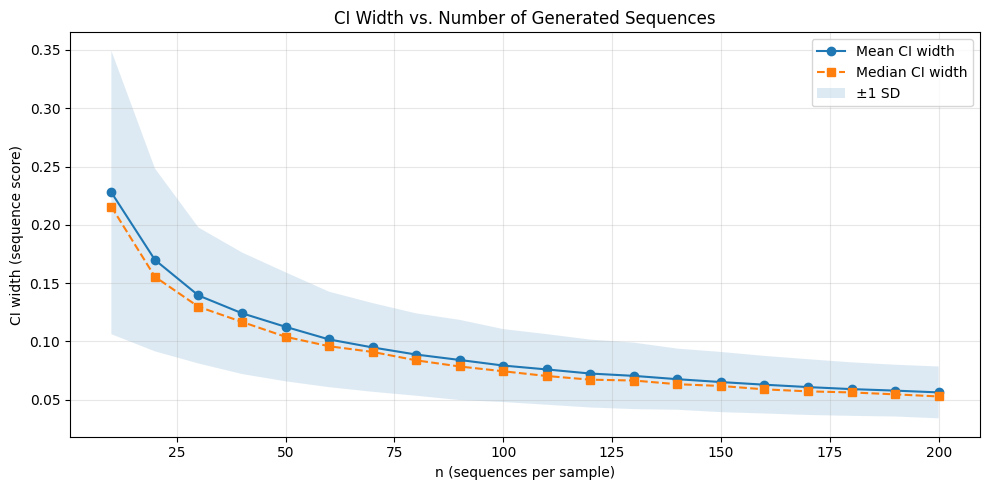

In [4]:
import matplotlib.pyplot as plt

summary = (
    ci_all
    .groupby('n_target')['ci_bootstrap_width']
    .agg(['mean', 'median', 'std'])
    .reset_index()
)

print(summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(summary['n_target'], summary['mean'],   marker='o', label='Mean CI width')
ax.plot(summary['n_target'], summary['median'], marker='s', label='Median CI width', linestyle='--')
ax.fill_between(
    summary['n_target'],
    summary['mean'] - summary['std'],
    summary['mean'] + summary['std'],
    alpha=0.15, label='±1 SD'
)
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('CI width (sequence score)')
ax.set_title('CI Width vs. Number of Generated Sequences')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

First n where marginal % improvement (mean width) drops below threshold:
───────────────────────────────────────────────────────
  <5.0% per +10 seqs  →  n = 110  (mean CI width = 0.0759,  marginal gain = 4.29%)
  <2.0%  →  not reached in data range
  <1.0%  →  not reached in data range
  <0.5%  →  not reached in data range

Geometric elbow (max curvature):  n = 60  (mean CI width = 0.1017)
Peak efficiency ratio:            n = 40

Diminishing Returns Table  (mean CI width, all n):
────────────────────────────────────────────────────────────────────────────────
  % improve vs prev         → marginal improvement going from n-10 to n
  cumul. % reduction        → total CI width reduction vs n=10 baseline
  width reduction / seq     → how much each additional sequence helps
  elbow distance            → distance from chord line (higher = more 'elbow-like')
  efficiency ratio          → cumulative gain / sqrt(cost)
───────────────────────────────────────────────────────────────────────────

,n,mean CI width,avg ± radius,% improve vs prev,cumul. % reduction,width reduction / seq,elbow distance,efficiency ratio
0,10,0.2277,0.1139,NaN,0.0,NaN,0.0000,0.0000
1,20,0.1699,0.0849,25.38,25.4,0.00578,0.2011,5.6796
2,30,0.1394,0.0697,17.95,38.8,0.00305,0.2896,7.0839
3,40,0.1241,0.0621,10.98,45.5,0.00153,0.3155,7.1942
4,50,0.1125,0.0562,9.35,50.6,0.00116,0.3261,7.1559
5,60,0.1017,0.0508,9.60,55.3,0.00108,0.3334,7.1392
6,70,0.0948,0.0474,6.78,58.4,0.00069,0.3247,6.9801
7,80,0.0887,0.0443,6.43,61.0,0.00061,0.3126,6.8200
8,90,0.0840,0.0420,5.30,63.1,0.00047,0.2948,6.6513
9,100,0.0793,0.0396,5.60,65.2,0.00047,0.2769,6.5200


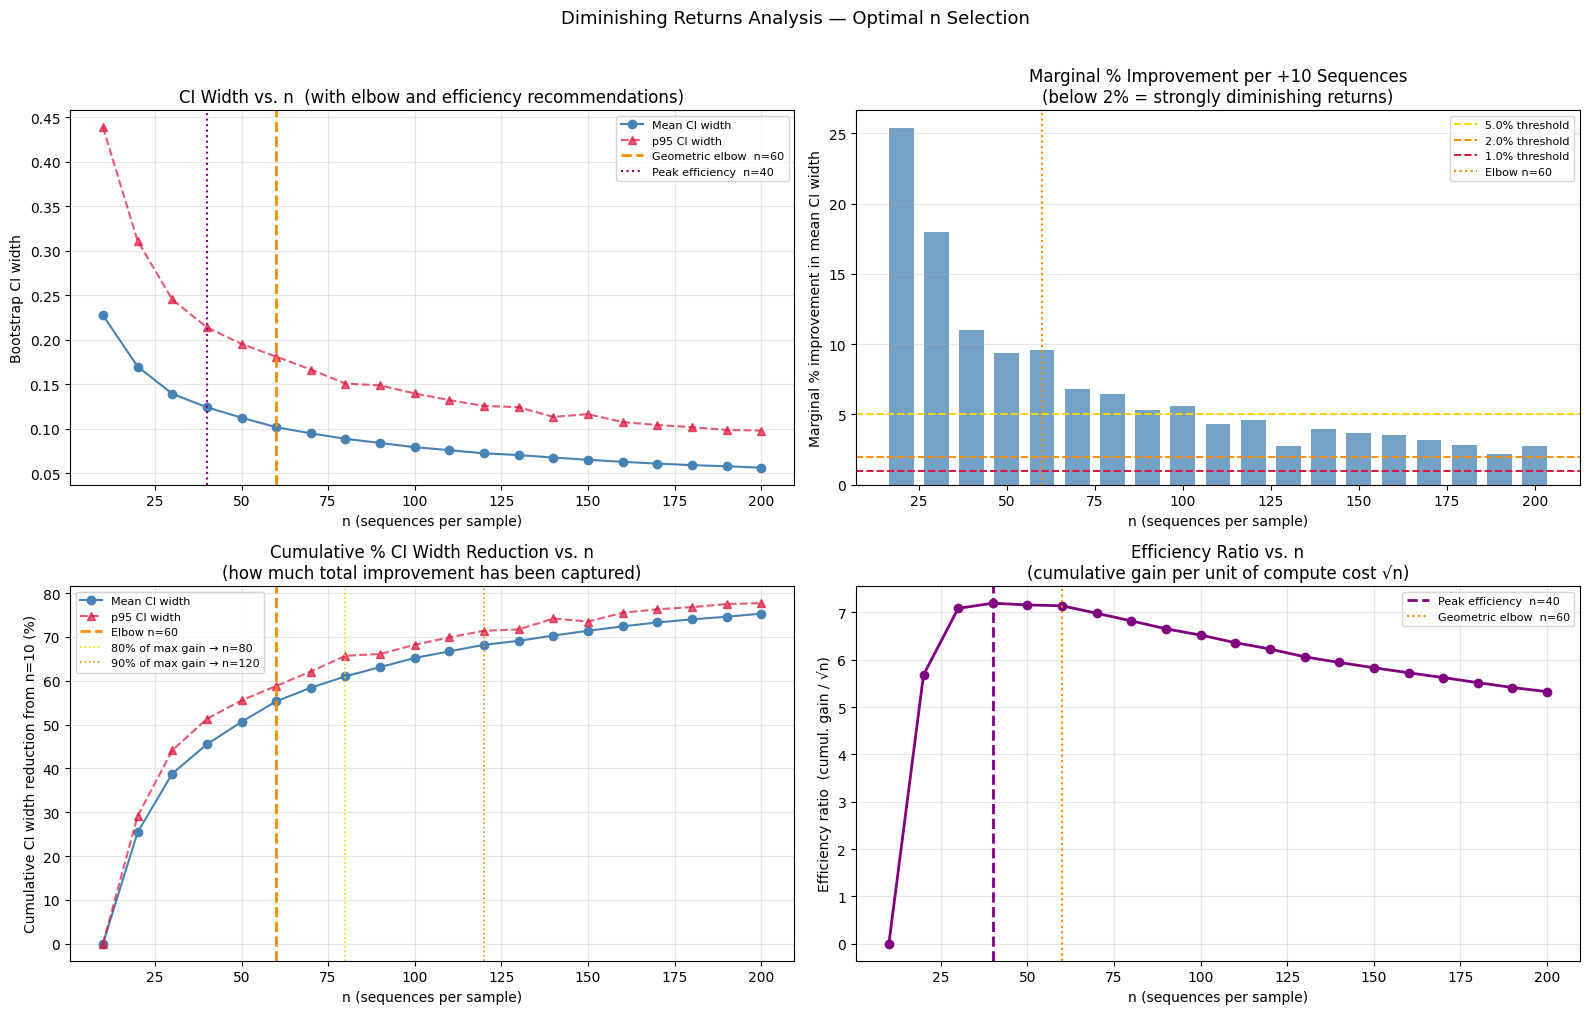


OPTIMAL n RECOMMENDATIONS
  Geometric elbow:             n =   60  (mean CI width ≈ 0.1017,  ±0.0508)
  Peak efficiency ratio:       n =   40
  Capture 80% of max CI gain:  n =   80
  Capture 90% of max CI gain:  n =  120
  Capture 95% of max CI gain:  n =  160
  Max total gain (n=10→200): 75.3% CI width reduction

  → For a balanced trade-off, n = 60 is the elbow.
    Beyond n = 120, each additional batch of 10 sequences
    reduces mean CI width by less than 4.6%.


In [11]:

# ============================================================
# DIMINISHING RETURNS ANALYSIS — Optimal n Selection
#   Three complementary methods to find where adding more
#   sequences stops meaningfully reducing CI width:
#
#   1. Marginal gain      — absolute CI width drop per +10 sequences
#   2. % improvement      — relative drop vs current width
#   3. Kneedle elbow      — geometric max-curvature of the curve
#   4. Efficiency ratio   — gain / cost  (normalised)
# ============================================================

# Build the marginal improvement table from p95_summary
# (has both mean and p95 width, and covers n=10..200)
dr = p95_summary[['n_target', 'mean_width', 'p95_width', 'avg_half_width', 'p95_half_width']].copy()
dr = dr.sort_values('n_target').reset_index(drop=True)

# ── Method 1 & 2: Marginal gain + % improvement ─────────────
dr['delta_mean']   = -dr['mean_width'].diff()          # positive = improvement
dr['delta_p95']    = -dr['p95_width'].diff()
dr['delta_n']      = dr['n_target'].diff()
dr['gain_per_seq_mean'] = dr['delta_mean'] / dr['delta_n']   # width reduction per sequence
dr['gain_per_seq_p95']  = dr['delta_p95']  / dr['delta_n']

# % improvement relative to the *previous* width
dr['pct_improve_mean'] = (dr['delta_mean'] / dr['mean_width'].shift(1) * 100).round(2)
dr['pct_improve_p95']  = (dr['delta_p95']  / dr['p95_width'].shift(1)  * 100).round(2)

# Cumulative % reduction from n=10 baseline
baseline_mean = dr.loc[0, 'mean_width']
baseline_p95  = dr.loc[0, 'p95_width']
dr['cum_reduce_mean'] = ((baseline_mean - dr['mean_width']) / baseline_mean * 100).round(1)
dr['cum_reduce_p95']  = ((baseline_p95  - dr['p95_width'])  / baseline_p95  * 100).round(1)

# ── Method 3: Geometric elbow (max distance from chord) ─────
# Normalise n and mean_width to [0,1], then find the point
# furthest from the straight line between first and last points.
n_arr = dr['n_target'].values.astype(float)
w_arr = dr['mean_width'].values

n_norm = (n_arr - n_arr.min()) / (n_arr.max() - n_arr.min())
w_norm = (w_arr - w_arr.min()) / (w_arr.max() - w_arr.min())

# Line from (0,1) to (1,0) in normalised space
# Distance of each point from that line
line_vec  = np.array([n_norm[-1] - n_norm[0], w_norm[-1] - w_norm[0]])
line_len  = np.linalg.norm(line_vec)
distances = np.abs(
    (w_norm[-1] - w_norm[0]) * n_norm -
    (n_norm[-1] - n_norm[0]) * w_norm +
    n_norm[-1] * w_norm[0] - w_norm[-1] * n_norm[0]
) / line_len

elbow_idx     = int(np.argmax(distances))
elbow_n       = int(n_arr[elbow_idx])
elbow_width   = float(w_arr[elbow_idx])
dr['elbow_distance'] = distances.round(4)

# ── Method 4: Efficiency ratio = cumulative gain / sqrt(cost) ──
# Higher = more gain per unit of compute cost
dr['efficiency'] = (dr['cum_reduce_mean'] / np.sqrt(dr['n_target'])).round(4)
efficiency_n = int(dr.loc[dr['efficiency'].idxmax(), 'n_target'])

# ── Threshold crossings ──────────────────────────────────────
thresholds_pct = [5.0, 2.0, 1.0, 0.5]
print("First n where marginal % improvement (mean width) drops below threshold:")
print("─" * 55)
for t in thresholds_pct:
    crossed = dr.dropna(subset=['pct_improve_mean'])
    crossed = crossed[crossed['pct_improve_mean'] < t]
    if not crossed.empty:
        n_c = int(crossed.iloc[0]['n_target'])
        p_c = crossed.iloc[0]['pct_improve_mean']
        w_c = crossed.iloc[0]['mean_width']
        print(f"  <{t:.1f}% per +10 seqs  →  n = {n_c}  "
              f"(mean CI width = {w_c:.4f},  marginal gain = {p_c:.2f}%)")
    else:
        print(f"  <{t:.1f}%  →  not reached in data range")

print(f"\nGeometric elbow (max curvature):  n = {elbow_n}  "
      f"(mean CI width = {elbow_width:.4f})")
print(f"Peak efficiency ratio:            n = {efficiency_n}")

# ── Display the full table ───────────────────────────────────
display_dr = dr[['n_target', 'mean_width', 'avg_half_width',
                 'pct_improve_mean', 'cum_reduce_mean',
                 'gain_per_seq_mean', 'elbow_distance', 'efficiency']].rename(columns={
    'n_target':         'n',
    'mean_width':       'mean CI width',
    'avg_half_width':   'avg ± radius',
    'pct_improve_mean': '% improve vs prev',
    'cum_reduce_mean':  'cumul. % reduction',
    'gain_per_seq_mean':'width reduction / seq',
    'elbow_distance':   'elbow distance',
    'efficiency':       'efficiency ratio',
}).round(5)

print("\nDiminishing Returns Table  (mean CI width, all n):")
print("─" * 80)
print("  % improve vs prev         → marginal improvement going from n-10 to n")
print("  cumul. % reduction        → total CI width reduction vs n=10 baseline")
print("  width reduction / seq     → how much each additional sequence helps")
print("  elbow distance            → distance from chord line (higher = more 'elbow-like')")
print("  efficiency ratio          → cumulative gain / sqrt(cost)")
print("─" * 80)
display(display_dr)

# ── Plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: CI width curve with elbow marked
ax = axes[0, 0]
ax.plot(dr['n_target'], dr['mean_width'],  marker='o', color='steelblue', label='Mean CI width')
ax.plot(dr['n_target'], dr['p95_width'],   marker='^', color='crimson',   label='p95 CI width',
        linestyle='--', alpha=0.7)
ax.axvline(elbow_n, color='darkorange', linewidth=2, linestyle='--',
           label=f'Geometric elbow  n={elbow_n}')
ax.axvline(efficiency_n, color='purple', linewidth=1.5, linestyle=':',
           label=f'Peak efficiency  n={efficiency_n}')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Bootstrap CI width')
ax.set_title('CI Width vs. n  (with elbow and efficiency recommendations)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Top-right: marginal % improvement per +10 sequences
ax = axes[0, 1]
valid_dr = dr.dropna(subset=['pct_improve_mean'])
ax.bar(valid_dr['n_target'], valid_dr['pct_improve_mean'],
       color='steelblue', alpha=0.75, width=7)
for t, col in zip([5.0, 2.0, 1.0], ['gold', 'darkorange', 'crimson']):
    ax.axhline(t, color=col, linewidth=1.4, linestyle='--', label=f'{t}% threshold')
ax.axvline(elbow_n, color='darkorange', linewidth=1.5, linestyle=':',
           label=f'Elbow n={elbow_n}')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Marginal % improvement in mean CI width')
ax.set_title('Marginal % Improvement per +10 Sequences\n(below 2% = strongly diminishing returns)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

# Bottom-left: cumulative % reduction
ax = axes[1, 0]
ax.plot(dr['n_target'], dr['cum_reduce_mean'],
        marker='o', color='steelblue', label='Mean CI width')
ax.plot(dr['n_target'], dr['cum_reduce_p95'],
        marker='^', color='crimson', linestyle='--', label='p95 CI width', alpha=0.7)
ax.axvline(elbow_n, color='darkorange', linewidth=2, linestyle='--',
           label=f'Elbow n={elbow_n}')
# Shade the "you've captured most of the gain" region
max_gain = dr['cum_reduce_mean'].max()
for pct, col, lbl in [(80, 'gold', '80% of max gain'), (90, 'darkorange', '90% of max gain')]:
    target = max_gain * pct / 100
    hit = dr[dr['cum_reduce_mean'] >= target]
    if not hit.empty:
        n_h = int(hit.iloc[0]['n_target'])
        ax.axvline(n_h, color=col, linewidth=1.2, linestyle=':', label=f'{pct}% of max gain → n={n_h}')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Cumulative CI width reduction from n=10 (%)')
ax.set_title('Cumulative % CI Width Reduction vs. n\n(how much total improvement has been captured)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Bottom-right: efficiency ratio
ax = axes[1, 1]
ax.plot(dr['n_target'], dr['efficiency'],
        marker='o', color='purple', linewidth=2)
ax.axvline(efficiency_n, color='purple', linewidth=2, linestyle='--',
           label=f'Peak efficiency  n={efficiency_n}')
ax.axvline(elbow_n, color='darkorange', linewidth=1.5, linestyle=':',
           label=f'Geometric elbow  n={elbow_n}')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Efficiency ratio  (cumul. gain / √n)')
ax.set_title('Efficiency Ratio vs. n\n(cumulative gain per unit of compute cost √n)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.suptitle('Diminishing Returns Analysis — Optimal n Selection', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# ── Final recommendation ─────────────────────────────────────
max_gain = dr['cum_reduce_mean'].max()
n_80 = int(dr[dr['cum_reduce_mean'] >= max_gain * 0.80].iloc[0]['n_target'])
n_90 = int(dr[dr['cum_reduce_mean'] >= max_gain * 0.90].iloc[0]['n_target'])
n_95 = int(dr[dr['cum_reduce_mean'] >= max_gain * 0.95].iloc[0]['n_target'])

w_elbow     = float(dr[dr['n_target'] == elbow_n]['mean_width'].values[0])
w_elbow_hz  = w_elbow / 2

print("\n" + "="*65)
print("OPTIMAL n RECOMMENDATIONS")
print("="*65)
print(f"  Geometric elbow:             n = {elbow_n:>4}  "
      f"(mean CI width ≈ {w_elbow:.4f},  ±{w_elbow_hz:.4f})")
print(f"  Peak efficiency ratio:       n = {efficiency_n:>4}")
print(f"  Capture 80% of max CI gain:  n = {n_80:>4}")
print(f"  Capture 90% of max CI gain:  n = {n_90:>4}")
print(f"  Capture 95% of max CI gain:  n = {n_95:>4}")
print(f"  Max total gain (n=10→{int(dr['n_target'].max())}): {max_gain:.1f}% CI width reduction")
print()
print(f"  → For a balanced trade-off, n = {elbow_n} is the elbow.")
print(f"    Beyond n = {n_90}, each additional batch of 10 sequences")
w_at_n90 = float(dr[dr['n_target'] == n_90]['pct_improve_mean'].values[0]) if n_90 in dr['n_target'].values else float('nan')
if not np.isnan(w_at_n90):
    print(f"    reduces mean CI width by less than {w_at_n90:.1f}%.")


Bootstrap 95% CI Boundaries per n  (95th-percentile across samples)
──────────────────────────────────────────────────────────────────────────────────────────
  avg lower / avg upper  →  where the CI sits for a typical sample
  avg ± radius           →  half of avg width  (the ± you'd quote for a typical sample)
  p5 lower  / p95 upper  →  how far the CI boundaries can reach (extreme samples)
  p95 width              →  worst-case full CI span (top 5% of high-variance samples)
  p95 ± radius           →  half of p95 width  (the ± you'd quote for worst-case samples)
──────────────────────────────────────────────────────────────────────────────────────────


,n,samples,avg lower,avg upper,avg ± radius,p5 lower,p95 upper,p95 width,p95 ± radius
0,10,500,0.2555,0.4832,0.1139,-0.0243,0.6948,0.4391,0.2196
1,20,500,0.2880,0.4579,0.0849,0.0191,0.6526,0.3114,0.1557
2,30,500,0.3038,0.4432,0.0697,0.0459,0.6270,0.2454,0.1227
3,40,500,0.3096,0.4338,0.0621,0.0801,0.6167,0.2140,0.1070
4,50,500,0.3180,0.4305,0.0562,0.0839,0.6127,0.1954,0.0977
5,60,1500,0.3222,0.4239,0.0508,0.0840,0.6137,0.1811,0.0906
6,70,500,0.3281,0.4229,0.0474,0.0948,0.6041,0.1666,0.0833
7,80,500,0.3304,0.4191,0.0443,0.1038,0.6049,0.1508,0.0754
8,90,500,0.3323,0.4164,0.0420,0.0958,0.6057,0.1487,0.0744
9,100,500,0.3342,0.4135,0.0396,0.1129,0.5973,0.1397,0.0699


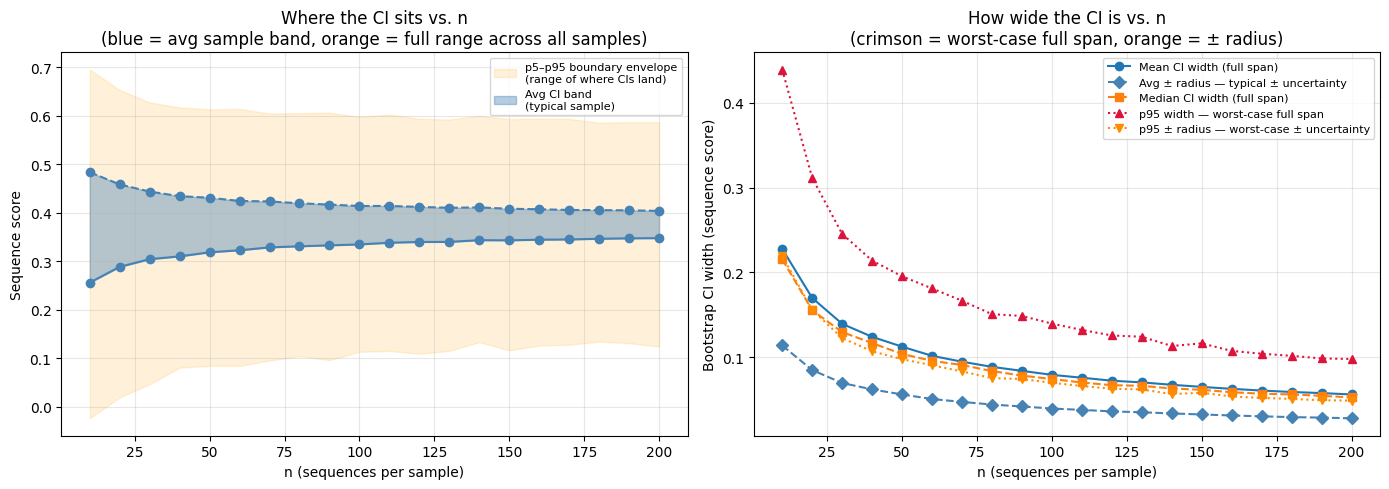


First n where avg CI ± radius ≤ threshold:
  ±0.050  →  n = 70  (avg ± radius = ±0.0474)
  ±0.075  →  n = 30  (avg ± radius = ±0.0697)
  ±0.100  →  n = 20  (avg ± radius = ±0.0849)
  ±0.125  →  n = 10  (avg ± radius = ±0.1139)

First n where p95 CI ± radius ≤ threshold:
  ±0.050  →  n = 190  (p95 ± radius = ±0.0493)
  ±0.075  →  n = 90  (p95 ± radius = ±0.0744)
  ±0.100  →  n = 50  (p95 ± radius = ±0.0977)
  ±0.125  →  n = 30  (p95 ± radius = ±0.1227)


In [5]:

# ============================================================
# p95 CI WIDTH PER FILE — 95th-percentile of bootstrap CI
#   Each CI was already computed at 95% confidence above.
#   Here we ask: for each n, what CI width covers 95% of samples?
# ============================================================

p95_summary = (
    ci_all
    .groupby('n_target')
    .agg(
        n_samples      = ('ci_bootstrap_width',  'count'),
        mean_width     = ('ci_bootstrap_width',  'mean'),
        median_width   = ('ci_bootstrap_width',  'median'),
        p95_width      = ('ci_bootstrap_width',  lambda x: np.percentile(x.dropna(), 95)),
        mean_ci_lower  = ('ci_bootstrap_lower',  'mean'),
        mean_ci_upper  = ('ci_bootstrap_upper',  'mean'),
        p5_ci_lower    = ('ci_bootstrap_lower',  lambda x: np.percentile(x.dropna(),  5)),
        p95_ci_upper   = ('ci_bootstrap_upper',  lambda x: np.percentile(x.dropna(), 95)),
    )
    .reset_index()
)

p95_summary['avg_half_width'] = p95_summary['mean_width'] / 2
p95_summary['p95_half_width'] = p95_summary['p95_width'] / 2
p95_summary = p95_summary.round(4)

# ── Friendly display table ──────────────────────────────────
display_table = p95_summary[[
    'n_target', 'n_samples',
    'mean_ci_lower', 'mean_ci_upper',   # average CI band across samples
    'avg_half_width',                   # ± radius for a typical sample
    'p5_ci_lower',   'p95_ci_upper',    # widest plausible CI boundaries
    'p95_width',     'p95_half_width',  # worst-case width / ± radius
]].rename(columns={
    'n_target':       'n',
    'n_samples':      'samples',
    'mean_ci_lower':  'avg lower',
    'mean_ci_upper':  'avg upper',
    'avg_half_width': 'avg ± radius',
    'p5_ci_lower':    'p5 lower',
    'p95_ci_upper':   'p95 upper',
    'p95_width':      'p95 width',
    'p95_half_width': 'p95 ± radius',
})

print("Bootstrap 95% CI Boundaries per n  (95th-percentile across samples)")
print("─" * 90)
print("  avg lower / avg upper  →  where the CI sits for a typical sample")
print("  avg ± radius           →  half of avg width  (the ± you'd quote for a typical sample)")
print("  p5 lower  / p95 upper  →  how far the CI boundaries can reach (extreme samples)")
print("  p95 width              →  worst-case full CI span (top 5% of high-variance samples)")
print("  p95 ± radius           →  half of p95 width  (the ± you'd quote for worst-case samples)")
print("─" * 90)
display(display_table)

# ── plot: boundaries + width ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: where the CI sits
ax = axes[0]
ax.fill_between(p95_summary['n_target'],
                p95_summary['p5_ci_lower'],
                p95_summary['p95_ci_upper'],
                alpha=0.15, label='p5–p95 boundary envelope\n(range of where CIs land)', color='orange')
ax.fill_between(p95_summary['n_target'],
                p95_summary['mean_ci_lower'],
                p95_summary['mean_ci_upper'],
                alpha=0.4, label='Avg CI band\n(typical sample)', color='steelblue')
ax.plot(p95_summary['n_target'], p95_summary['mean_ci_lower'],
        marker='o', color='steelblue', linewidth=1.5)
ax.plot(p95_summary['n_target'], p95_summary['mean_ci_upper'],
        marker='o', color='steelblue', linewidth=1.5, linestyle='--')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Sequence score')
ax.set_title('Where the CI sits vs. n\n(blue = avg sample band, orange = full range across all samples)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Right: how wide the CI is
ax = axes[1]
ax.plot(p95_summary['n_target'], p95_summary['mean_width'],
        marker='o',  label='Mean CI width (full span)')
ax.plot(p95_summary['n_target'], p95_summary['avg_half_width'],
        marker='D',  label='Avg ± radius — typical ± uncertainty', linestyle='--', color='steelblue')
ax.plot(p95_summary['n_target'], p95_summary['median_width'],
        marker='s',  label='Median CI width (full span)', linestyle='--')
ax.plot(p95_summary['n_target'], p95_summary['p95_width'],
        marker='^',  label='p95 width — worst-case full span', linestyle=':', color='crimson')
ax.plot(p95_summary['n_target'], p95_summary['p95_half_width'],
        marker='v',  label='p95 ± radius — worst-case ± uncertainty', linestyle=':', color='darkorange')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Bootstrap CI width (sequence score)')
ax.set_title('How wide the CI is vs. n\n(crimson = worst-case full span, orange = ± radius)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── elbow: first n where HALF-width drops below threshold ──
thresholds = [0.05, 0.075, 0.10, 0.125]
print("\nFirst n where avg CI ± radius ≤ threshold:")
for t in thresholds:
    hit = p95_summary[p95_summary['avg_half_width'] <= t]
    if not hit.empty:
        n_hit = int(hit.iloc[0]['n_target'])
        w_hit = hit.iloc[0]['avg_half_width']
        print(f"  ±{t:.3f}  →  n = {n_hit}  (avg ± radius = ±{w_hit:.4f})")
    else:
        print(f"  ±{t:.3f}  →  not reached in available data")

print("\nFirst n where p95 CI ± radius ≤ threshold:")
for t in thresholds:
    hit = p95_summary[p95_summary['p95_half_width'] <= t]
    if not hit.empty:
        n_hit = int(hit.iloc[0]['n_target'])
        w_hit = hit.iloc[0]['p95_half_width']
        print(f"  ±{t:.3f}  →  n = {n_hit}  (p95 ± radius = ±{w_hit:.4f})")
    else:
        print(f"  ±{t:.3f}  →  not reached in available data")


Enriched CI records: 14000  (abs_prediction_error nulls: 0)

Correlation: CI Width vs. Prediction Error  (vs. Semantic Entropy baseline)
────────────────────────────────────────────────────────────────────────────────
  pearson_r / spearman_r  →  monotonic link between uncertainty signal and error
  auroc                   →  how well the signal discriminates high-error samples
  ci_*  = bootstrap CI width signal
  se_*  = semantic entropy signal (baseline)
────────────────────────────────────────────────────────────────────────────────


,n_target,n_samples,ci_pearson_r,ci_pearson_p,ci_spearman_r,ci_spearman_p,ci_auroc,se_pearson_r,se_pearson_p,se_spearman_r,se_spearman_p,se_auroc
0,10,500,0.0047,0.9162,-0.0207,0.6444,0.4847,-0.0056,0.9013,-0.0309,0.4912,0.4815
1,20,500,0.0162,0.7172,0.0025,0.9548,0.5010,0.0335,0.4545,0.0472,0.2924,0.5107
2,30,500,0.0093,0.8359,-0.0257,0.5670,0.4690,0.0202,0.6528,-0.0064,0.8867,0.4898
3,40,500,-0.0217,0.6286,-0.0376,0.4010,0.4746,0.0349,0.4356,0.0570,0.2028,0.5112
4,50,500,0.0037,0.9342,-0.0080,0.8579,0.4831,0.1263,0.0047,0.1020,0.0225,0.5400
5,60,4500,-0.0156,0.2940,-0.0355,0.0171,0.4755,0.0607,0.0000,0.0757,0.0000,0.5216
6,70,500,-0.0258,0.5653,-0.0278,0.5358,0.4715,-0.0066,0.8829,0.0524,0.2424,0.5049
7,80,500,-0.0092,0.8371,-0.0371,0.4079,0.4762,0.0179,0.6891,0.0166,0.7116,0.4949
8,90,500,0.0047,0.9162,-0.0217,0.6280,0.4755,0.1037,0.0204,0.0621,0.1656,0.5076
9,100,500,0.0166,0.7112,-0.0017,0.9699,0.4858,0.0227,0.6133,-0.0008,0.9851,0.4806


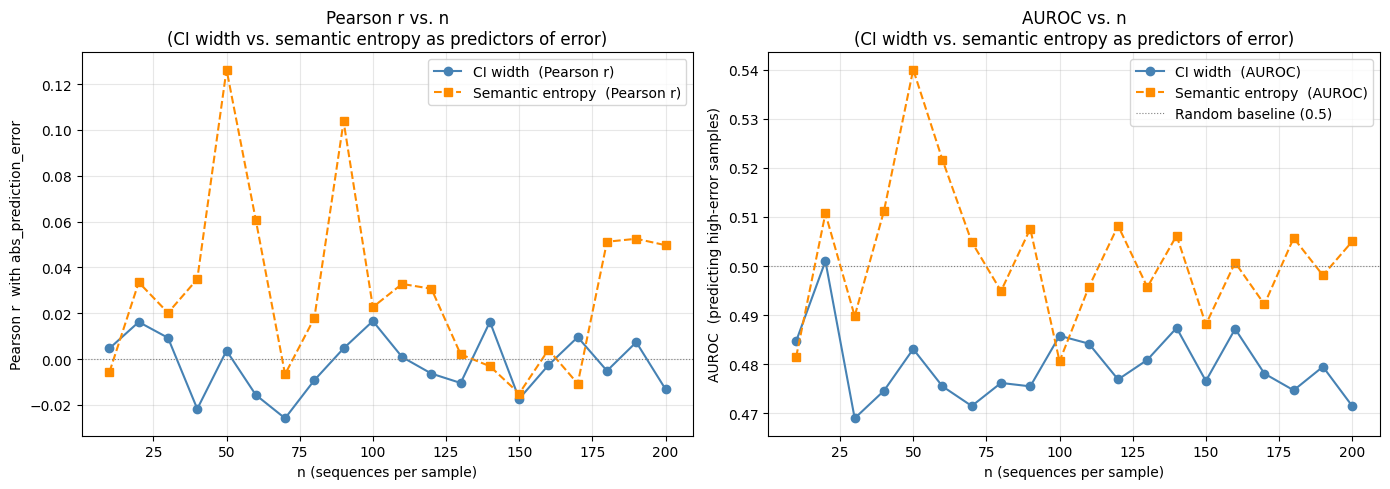


At n=200:
  CI width     →  Pearson r=-0.0131 (p=0.7694),  Spearman r=-0.0312,  AUROC=0.4715
  Sem. entropy →  Pearson r=0.0497 (p=0.2677),  Spearman r=0.0408,  AUROC=0.5050


In [6]:

# ============================================================
# DIRECT CORRELATION: CI Width vs. Prediction Error
#   Does a wider bootstrap CI (more stochastic variance)
#   predict a larger absolute prediction error?
#   Compared side-by-side with semantic_entropy as a baseline.
#
#   NOTE: abs_prediction_error comes from the greedy/metrics tables
#   (the column was named 'error' in stochastic rows before renaming),
#   so we join ci_all against metrics_dfs on sample_key + n_target.
# ============================================================

# Build a single metrics lookup: sample_key + n_target → error + entropy
metrics_all = pd.concat(
    [df[['sample_key', 'n_target', 'abs_prediction_error', 'semantic_entropy']]
     for df in metrics_dfs.values()
     if 'abs_prediction_error' in df.columns],
    ignore_index=True
)

# Join CI width onto it
ci_enriched = ci_all[['sample_key', 'n_target', 'ci_bootstrap_width']].merge(
    metrics_all,
    on=['sample_key', 'n_target'],
    how='inner'
)

print(f"Enriched CI records: {len(ci_enriched)}  "
      f"(abs_prediction_error nulls: {ci_enriched['abs_prediction_error'].isna().sum()})")

# ── Compute correlations per n ─────────────────────────────
corr_records = []

for n_target, grp in ci_enriched.groupby('n_target'):
    df = grp.dropna(subset=['ci_bootstrap_width', 'abs_prediction_error']).copy()
    if len(df) < 10:
        continue

    error_threshold     = df['abs_prediction_error'].median()
    df['is_high_error'] = (df['abs_prediction_error'] > error_threshold).astype(int)

    # CI width vs error
    ci_pearson_r,  ci_pearson_p  = pearsonr( df['ci_bootstrap_width'], df['abs_prediction_error'])
    ci_spearman_r, ci_spearman_p = spearmanr(df['ci_bootstrap_width'], df['abs_prediction_error'])
    ci_auroc = roc_auc_score(df['is_high_error'], df['ci_bootstrap_width'])

    row = {
        'n_target':      n_target,
        'n_samples':     len(df),
        'ci_pearson_r':  round(ci_pearson_r,  4),
        'ci_pearson_p':  round(ci_pearson_p,  4),
        'ci_spearman_r': round(ci_spearman_r, 4),
        'ci_spearman_p': round(ci_spearman_p, 4),
        'ci_auroc':      round(ci_auroc,       4),
    }

    # Semantic entropy vs error (baseline)
    df_se = df.dropna(subset=['semantic_entropy'])
    if len(df_se) >= 10:
        se_pearson_r,  se_pearson_p  = pearsonr( df_se['semantic_entropy'], df_se['abs_prediction_error'])
        se_spearman_r, se_spearman_p = spearmanr(df_se['semantic_entropy'], df_se['abs_prediction_error'])
        se_auroc = roc_auc_score(df_se['is_high_error'], df_se['semantic_entropy'])
        row.update({
            'se_pearson_r':  round(se_pearson_r,  4),
            'se_pearson_p':  round(se_pearson_p,  4),
            'se_spearman_r': round(se_spearman_r, 4),
            'se_spearman_p': round(se_spearman_p, 4),
            'se_auroc':      round(se_auroc,       4),
        })
    else:
        row.update({k: np.nan for k in
                    ['se_pearson_r', 'se_pearson_p', 'se_spearman_r', 'se_spearman_p', 'se_auroc']})

    corr_records.append(row)

corr_df = (
    pd.DataFrame(corr_records)
    .sort_values('n_target')
    .reset_index(drop=True)
)

print("\nCorrelation: CI Width vs. Prediction Error  (vs. Semantic Entropy baseline)")
print("─" * 80)
print("  pearson_r / spearman_r  →  monotonic link between uncertainty signal and error")
print("  auroc                   →  how well the signal discriminates high-error samples")
print("  ci_*  = bootstrap CI width signal")
print("  se_*  = semantic entropy signal (baseline)")
print("─" * 80)
display(corr_df)

# ── Plot: AUROC and Pearson r vs n ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(corr_df['n_target'], corr_df['ci_pearson_r'],
        marker='o', label='CI width  (Pearson r)', color='steelblue')
ax.plot(corr_df['n_target'], corr_df['se_pearson_r'],
        marker='s', label='Semantic entropy  (Pearson r)', color='darkorange', linestyle='--')
ax.axhline(0, color='grey', linewidth=0.8, linestyle=':')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('Pearson r  with abs_prediction_error')
ax.set_title('Pearson r vs. n\n(CI width vs. semantic entropy as predictors of error)')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(corr_df['n_target'], corr_df['ci_auroc'],
        marker='o', label='CI width  (AUROC)', color='steelblue')
ax.plot(corr_df['n_target'], corr_df['se_auroc'],
        marker='s', label='Semantic entropy  (AUROC)', color='darkorange', linestyle='--')
ax.axhline(0.5, color='grey', linewidth=0.8, linestyle=':', label='Random baseline (0.5)')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('AUROC  (predicting high-error samples)')
ax.set_title('AUROC vs. n\n(CI width vs. semantic entropy as predictors of error)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ── Summary at highest n ───────────────────────────────────
best = corr_df.loc[corr_df['n_target'].idxmax()]
print(f"\nAt n={int(best['n_target'])}:")
print(f"  CI width     →  Pearson r={best['ci_pearson_r']:.4f} (p={best['ci_pearson_p']:.4f}),  "
      f"Spearman r={best['ci_spearman_r']:.4f},  AUROC={best['ci_auroc']:.4f}")
print(f"  Sem. entropy →  Pearson r={best['se_pearson_r']:.4f} (p={best['se_pearson_p']:.4f}),  "
      f"Spearman r={best['se_spearman_r']:.4f},  AUROC={best['se_auroc']:.4f}")


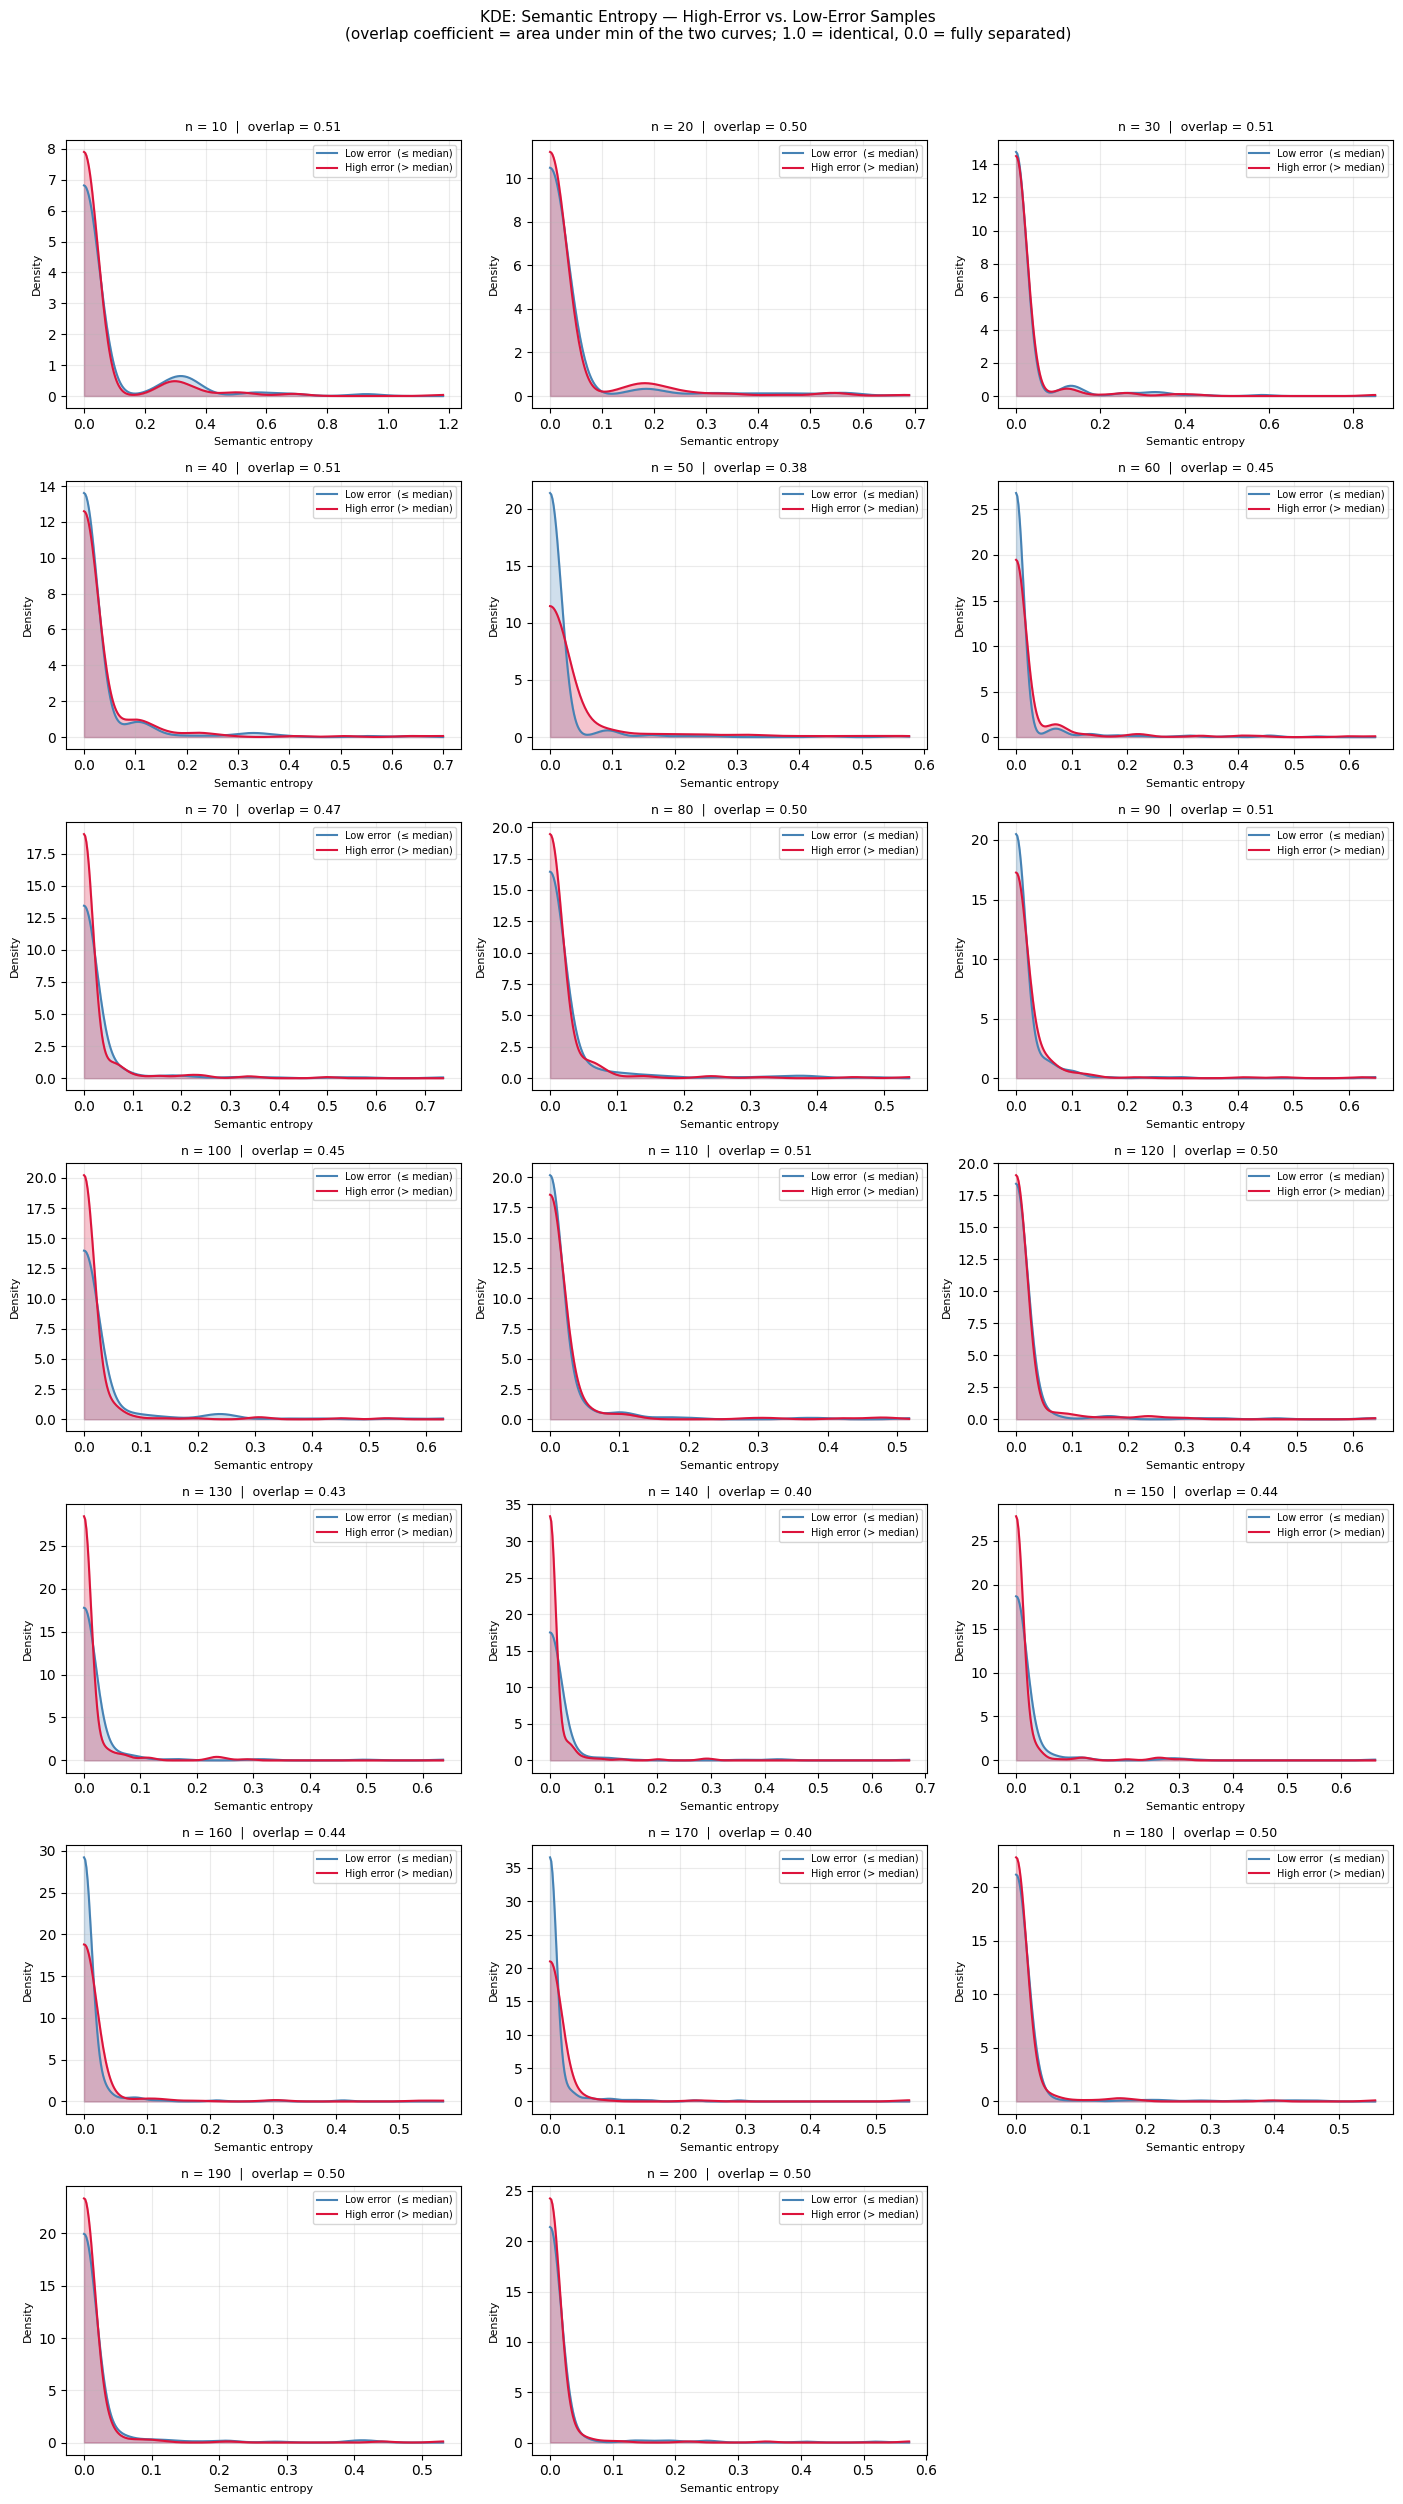


Overlap coefficient per n  (1.0 = distributions identical, 0.0 = fully separated)
───────────────────────────────────────────────────────
  A high overlap explains the low AUROC — the model's
  entropy distribution barely differs between samples
  it gets right vs. wrong.
───────────────────────────────────────────────────────


,n_target,overlap_coeff
0,10,0.5060
1,20,0.5030
2,30,0.5108
3,40,0.5146
4,50,0.3845
5,60,0.4549
6,70,0.4690
7,80,0.4952
8,90,0.5072
9,100,0.4500


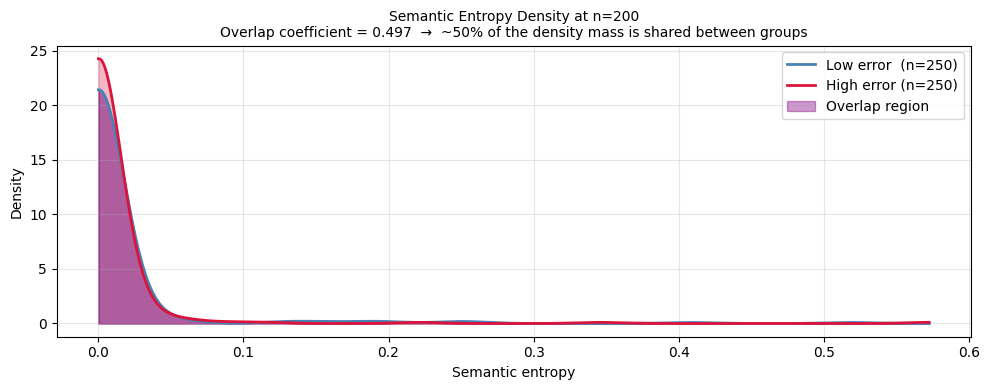


At n=200: overlap coefficient = 0.497
  → The high-error and low-error entropy distributions share ~50% of their mass.
  → This is why AUROC ≈ 0.54 — entropy alone cannot reliably separate the two groups.
  → The model is confidently wrong on many samples, giving them low entropy despite high error.


In [7]:

# ============================================================
# DENSITY ANALYSIS: Semantic Entropy Distribution
#   High-error vs. low-error samples — KDE overlay
#   Shows WHY AUROC ≈ 0.54: the two groups barely separate
# ============================================================
from scipy.stats import gaussian_kde

_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

# Use ci_enriched (has both semantic_entropy and abs_prediction_error, 0 nulls)
plot_ns = sorted(ci_enriched['n_target'].unique())

# ── Per-n KDE subplot grid ──────────────────────────────────
ncols = 3
nrows = -(-len(plot_ns) // ncols)   # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3.5))
axes_flat = axes.flatten()

overlap_records = []

for i, n_val in enumerate(plot_ns):
    ax = axes_flat[i]
    grp = ci_enriched[ci_enriched['n_target'] == n_val].dropna(
        subset=['semantic_entropy', 'abs_prediction_error'])

    threshold = grp['abs_prediction_error'].median()
    low_err  = grp[grp['abs_prediction_error'] <= threshold]['semantic_entropy'].values
    high_err = grp[grp['abs_prediction_error'] >  threshold]['semantic_entropy'].values

    # KDE over a shared grid
    x_min = grp['semantic_entropy'].min()
    x_max = grp['semantic_entropy'].max()
    x_grid = np.linspace(x_min, x_max, 300)

    for vals, label, color in [
        (low_err,  'Low error  (≤ median)', 'steelblue'),
        (high_err, 'High error (> median)', 'crimson'),
    ]:
        if len(np.unique(vals)) < 2:
            continue
        kde = gaussian_kde(vals, bw_method='scott')
        ax.fill_between(x_grid, kde(x_grid), alpha=0.25, color=color)
        ax.plot(x_grid, kde(x_grid), color=color, linewidth=1.5, label=label)

    ax.set_xlabel('Semantic entropy', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

    # Overlap coefficient: integral of min(kde_low, kde_high)
    if len(np.unique(low_err)) >= 2 and len(np.unique(high_err)) >= 2:
        kde_low_vals  = gaussian_kde(low_err,  bw_method='scott')(x_grid)
        kde_high_vals = gaussian_kde(high_err, bw_method='scott')(x_grid)
        dx = x_grid[1] - x_grid[0]
        overlap = float(_trapz(np.minimum(kde_low_vals, kde_high_vals), dx=dx))
        overlap_records.append({'n_target': n_val, 'overlap_coeff': round(overlap, 4)})
        ax.set_title(f'n = {n_val}  |  overlap = {overlap:.2f}', fontsize=9)
    else:
        ax.set_title(f'n = {n_val}', fontsize=10)

# Hide unused subplots
for j in range(len(plot_ns), len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.suptitle(
    'KDE: Semantic Entropy — High-Error vs. Low-Error Samples\n'
    '(overlap coefficient = area under min of the two curves; 1.0 = identical, 0.0 = fully separated)',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── Overlap coefficient table ───────────────────────────────
overlap_df = pd.DataFrame(overlap_records).sort_values('n_target').reset_index(drop=True)
print("\nOverlap coefficient per n  (1.0 = distributions identical, 0.0 = fully separated)")
print("─" * 55)
print("  A high overlap explains the low AUROC — the model's")
print("  entropy distribution barely differs between samples")
print("  it gets right vs. wrong.")
print("─" * 55)
display(overlap_df)

# ── Single combined plot at highest n ───────────────────────
best_n = int(ci_enriched['n_target'].max())
grp = ci_enriched[ci_enriched['n_target'] == best_n].dropna(
    subset=['semantic_entropy', 'abs_prediction_error'])

threshold = grp['abs_prediction_error'].median()
low_err  = grp[grp['abs_prediction_error'] <= threshold]['semantic_entropy'].values
high_err = grp[grp['abs_prediction_error'] >  threshold]['semantic_entropy'].values

x_grid = np.linspace(grp['semantic_entropy'].min(), grp['semantic_entropy'].max(), 500)
kde_low  = gaussian_kde(low_err,  bw_method='scott')
kde_high = gaussian_kde(high_err, bw_method='scott')

fig, ax = plt.subplots(figsize=(10, 4))
ax.fill_between(x_grid, kde_low(x_grid),  alpha=0.3, color='steelblue')
ax.fill_between(x_grid, kde_high(x_grid), alpha=0.3, color='crimson')
ax.plot(x_grid, kde_low(x_grid),  color='steelblue', linewidth=2, label=f'Low error  (n={len(low_err)})')
ax.plot(x_grid, kde_high(x_grid), color='crimson',   linewidth=2, label=f'High error (n={len(high_err)})')

# Shade overlap region
ax.fill_between(x_grid, np.minimum(kde_low(x_grid), kde_high(x_grid)),
                alpha=0.4, color='purple', label='Overlap region')

dx = x_grid[1] - x_grid[0]
ov = float(_trapz(np.minimum(kde_low(x_grid), kde_high(x_grid)), dx=dx))
ax.set_title(
    f'Semantic Entropy Density at n={best_n}\n'
    f'Overlap coefficient = {ov:.3f}  →  ~{ov*100:.0f}% of the density mass is shared between groups',
    fontsize=10
)
ax.set_xlabel('Semantic entropy')
ax.set_ylabel('Density')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nAt n={best_n}: overlap coefficient = {ov:.3f}")
print(f"  → The high-error and low-error entropy distributions share ~{ov*100:.0f}% of their mass.")
print(f"  → This is why AUROC ≈ 0.54 — entropy alone cannot reliably separate the two groups.")
print(f"  → The model is confidently wrong on many samples, giving them low entropy despite high error.")

Samples at n=200: 500
Global error median: 0.0595

Creativity bucket counts:
creativity_bucket
0.0–0.1      0
0.1–0.2      8
0.2–0.3     30
0.3–0.4    109
0.4–0.5    139
0.5–0.6     93
0.6–0.7     79
0.7–0.8     31
0.8–0.9     10
0.9–1.0      1
1.0–1.1      0

Per-bucket analysis  (n=200):
──────────────────────────────────────────────────────────────────────────────────────────
  mean_error          → avg |pred - true| in that creativity range
  mean_entropy        → avg semantic entropy (how uncertain the model is)
  auroc               → how well entropy predicts high-error samples within bucket
  overlap_coeff       → KDE overlap between high/low error entropy distributions
  pct_confident_wrong → % of samples with entropy≈0 but above-median error
──────────────────────────────────────────────────────────────────────────────────────────


,bucket,n_samples,mean_error,mean_entropy,pct_confident_wrong,auroc,overlap_coeff
0,0.1–0.2,8,0.1303,0.0140,50.0,0.7143,NaN
1,0.2–0.3,30,0.0773,0.0063,53.3,0.4887,0.1815
2,0.3–0.4,109,0.0661,0.0052,42.2,0.5146,0.3555
3,0.4–0.5,139,0.0592,0.0053,40.3,0.4857,0.1347
4,0.5–0.6,93,0.0634,0.0056,36.6,0.5153,0.3562
5,0.6–0.7,79,0.0885,0.0147,58.2,0.4286,0.1760
6,0.7–0.8,31,0.1091,0.0256,58.1,0.5045,0.3532
7,0.8–0.9,10,0.1938,0.0439,60.0,NaN,NaN


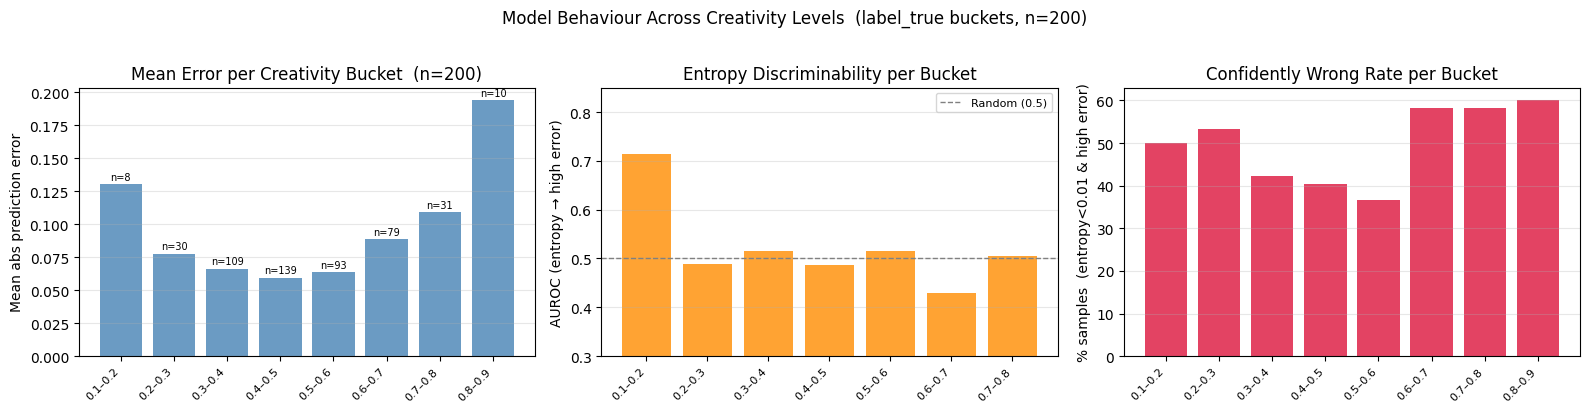

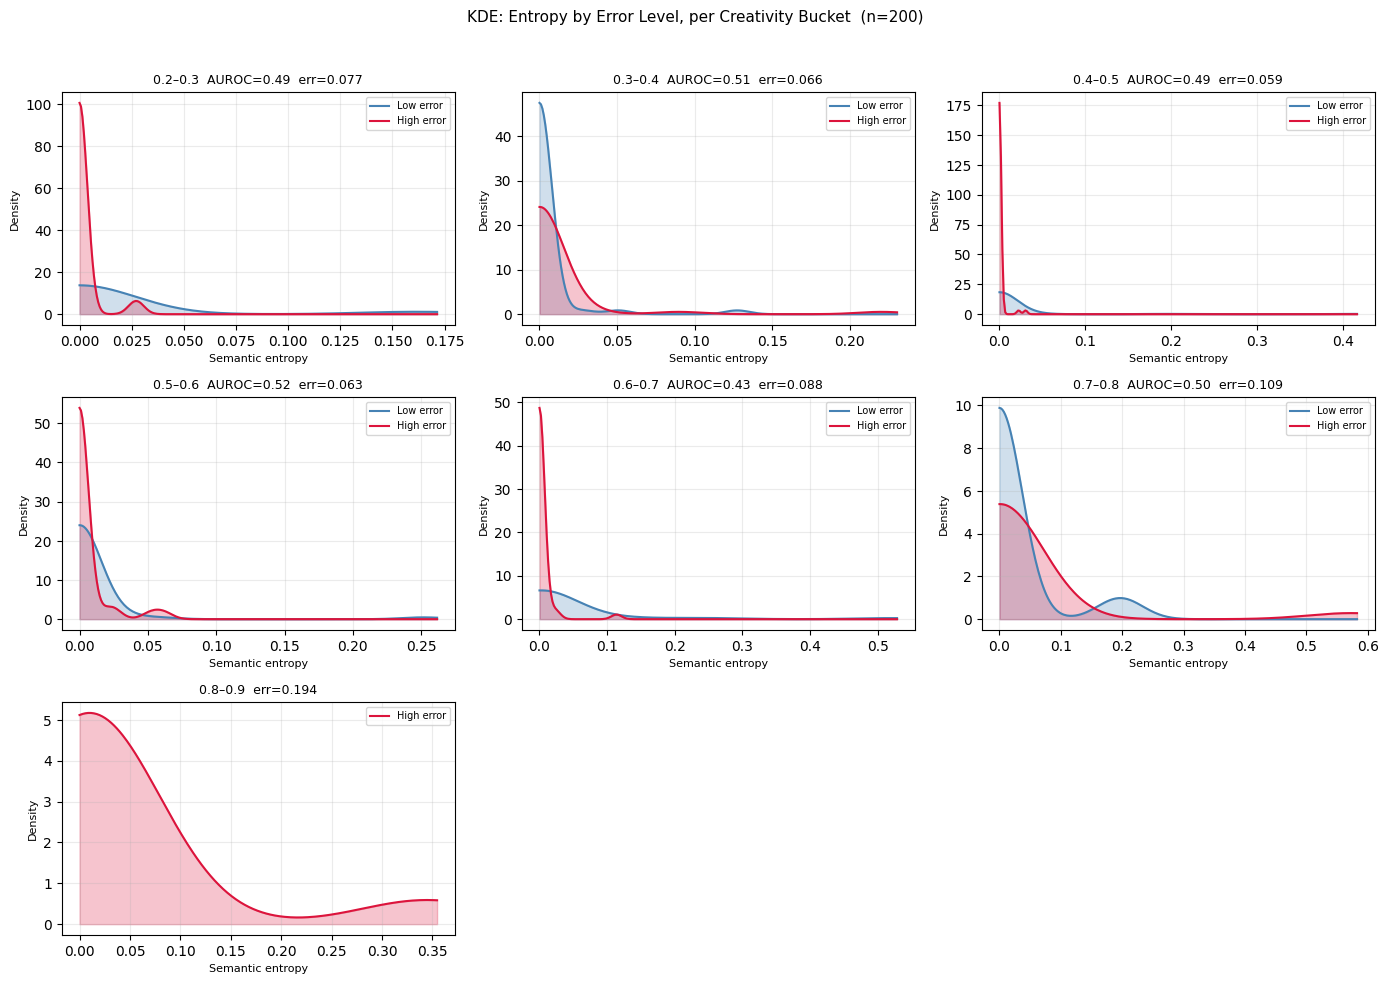


Key findings at n=200:
  Highest mean error bucket:          0.8–0.9  (error=0.1938)
  Worst entropy discriminability:     0.6–0.7  (AUROC=0.4286)
  Most confidently-wrong bucket:      0.8–0.9  (60.0% of samples)


In [8]:

# ============================================================
# CREATIVITY-LEVEL BUCKET ANALYSIS
#   Bucket samples by label_true in 0.10 increments.
#   For each bucket at n=60: mean error, entropy KDE,
#   AUROC, overlap coefficient, and % confidently wrong.
# ============================================================
from scipy.stats import gaussian_kde

_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz

# ── 1. Add label_true to ci_enriched ───────────────────────
metrics_label = pd.concat(
    [df[['sample_key', 'n_target', 'label_true']]
     for df in metrics_dfs.values()
     if 'label_true' in df.columns],
    ignore_index=True
)

ci_labeled = ci_enriched.merge(metrics_label, on=['sample_key', 'n_target'], how='inner')

# ── 2. Assign creativity buckets ───────────────────────────
bins   = np.arange(0.0, 1.11, 0.10)
labels = [f'{b:.1f}–{b+0.10:.1f}' for b in bins[:-1]]
ci_labeled['creativity_bucket'] = pd.cut(
    ci_labeled['label_true'], bins=bins, labels=labels,
    include_lowest=True, right=False
)

# Work at highest n only (most sequences = most stable estimates)
best_n  = int(ci_labeled['n_target'].max())
df_best = ci_labeled[ci_labeled['n_target'] == best_n].dropna(
    subset=['semantic_entropy', 'abs_prediction_error', 'creativity_bucket']
).copy()

global_error_median = df_best['abs_prediction_error'].median()
df_best['is_high_error']       = (df_best['abs_prediction_error'] > global_error_median).astype(int)
df_best['is_confident_wrong']  = (
    (df_best['semantic_entropy'] < 0.01) &
    (df_best['abs_prediction_error'] > global_error_median)
)

print(f"Samples at n={best_n}: {len(df_best)}")
print(f"Global error median: {global_error_median:.4f}\n")
print("Creativity bucket counts:")
print(df_best['creativity_bucket'].value_counts().sort_index().to_string())

# ── 3. Per-bucket stats table ───────────────────────────────
bucket_records = []

for bucket, bgrp in df_best.groupby('creativity_bucket', observed=True):
    if len(bgrp) < 5:
        continue

    n_samp    = len(bgrp)
    mean_err  = bgrp['abs_prediction_error'].mean()
    mean_ent  = bgrp['semantic_entropy'].mean()
    pct_conf_wrong = bgrp['is_confident_wrong'].mean() * 100

    row = {'bucket': bucket, 'n_samples': n_samp,
           'mean_error': round(mean_err, 4),
           'mean_entropy': round(mean_ent, 4),
           'pct_confident_wrong': round(pct_conf_wrong, 1)}

    # AUROC + overlap (need both classes present)
    if bgrp['is_high_error'].nunique() == 2:
        from sklearn.metrics import roc_auc_score as _auroc
        try:
            row['auroc'] = round(_auroc(bgrp['is_high_error'], bgrp['semantic_entropy']), 4)
        except Exception:
            row['auroc'] = np.nan

        lo = bgrp[bgrp['is_high_error'] == 0]['semantic_entropy'].values
        hi = bgrp[bgrp['is_high_error'] == 1]['semantic_entropy'].values
        if len(np.unique(lo)) >= 2 and len(np.unique(hi)) >= 2:
            xg = np.linspace(bgrp['semantic_entropy'].min(), bgrp['semantic_entropy'].max(), 200)
            ov = float(_trapz(np.minimum(
                gaussian_kde(lo)(xg), gaussian_kde(hi)(xg)), dx=xg[1]-xg[0]))
            row['overlap_coeff'] = round(ov, 4)
        else:
            row['overlap_coeff'] = np.nan
    else:
        row['auroc'] = np.nan
        row['overlap_coeff'] = np.nan

    bucket_records.append(row)

bucket_df = pd.DataFrame(bucket_records)

print("\nPer-bucket analysis  (n={}):".format(best_n))
print("─" * 90)
print("  mean_error          → avg |pred - true| in that creativity range")
print("  mean_entropy        → avg semantic entropy (how uncertain the model is)")
print("  auroc               → how well entropy predicts high-error samples within bucket")
print("  overlap_coeff       → KDE overlap between high/low error entropy distributions")
print("  pct_confident_wrong → % of samples with entropy≈0 but above-median error")
print("─" * 90)
display(bucket_df)

# ── 4. Three-panel summary plot ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

x     = np.arange(len(bucket_df))
xlabs = bucket_df['bucket'].astype(str)

ax = axes[0]
bars = ax.bar(x, bucket_df['mean_error'], color='steelblue', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(xlabs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Mean abs prediction error')
ax.set_title(f'Mean Error per Creativity Bucket  (n={best_n})')
ax.grid(True, alpha=0.3, axis='y')
# Annotate counts
for b, v, c in zip(x, bucket_df['mean_error'], bucket_df['n_samples']):
    ax.text(b, v + 0.002, f'n={c}', ha='center', va='bottom', fontsize=7)

ax = axes[1]
valid = bucket_df.dropna(subset=['auroc'])
ax.bar(np.arange(len(valid)), valid['auroc'], color='darkorange', alpha=0.8)
ax.axhline(0.5, color='grey', linewidth=1, linestyle='--', label='Random (0.5)')
ax.set_xticks(np.arange(len(valid)))
ax.set_xticklabels(valid['bucket'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('AUROC (entropy → high error)')
ax.set_title('Entropy Discriminability per Bucket')
ax.set_ylim(0.3, 0.85)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')

ax = axes[2]
ax.bar(x, bucket_df['pct_confident_wrong'], color='crimson', alpha=0.8)
ax.set_xticks(x); ax.set_xticklabels(xlabs, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('% samples  (entropy<0.01 & high error)')
ax.set_title('Confidently Wrong Rate per Bucket')
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle(
    f'Model Behaviour Across Creativity Levels  (label_true buckets, n={best_n})',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

# ── 5. KDE overlay per bucket ───────────────────────────────
buckets_with_data = [b for b in bucket_df['bucket'] if
                     len(df_best[df_best['creativity_bucket'] == b]) >= 10]
ncols_k = 3
nrows_k  = -(-len(buckets_with_data) // ncols_k)
fig, axes_k = plt.subplots(nrows_k, ncols_k, figsize=(14, nrows_k * 3.2))
axes_kf = axes_k.flatten()

for i, bucket in enumerate(buckets_with_data):
    ax = axes_kf[i]
    bgrp = df_best[df_best['creativity_bucket'] == bucket]
    lo   = bgrp[bgrp['is_high_error'] == 0]['semantic_entropy'].values
    hi   = bgrp[bgrp['is_high_error'] == 1]['semantic_entropy'].values
    xg   = np.linspace(bgrp['semantic_entropy'].min(), bgrp['semantic_entropy'].max() + 0.01, 250)

    for vals, lbl, col in [(lo, 'Low error', 'steelblue'), (hi, 'High error', 'crimson')]:
        if len(np.unique(vals)) >= 2:
            k = gaussian_kde(vals, bw_method='scott')
            ax.fill_between(xg, k(xg), alpha=0.25, color=col)
            ax.plot(xg, k(xg), color=col, linewidth=1.5, label=lbl)

    row_b = bucket_df[bucket_df['bucket'] == bucket].iloc[0]
    title_parts = [str(bucket)]
    if not np.isnan(row_b['auroc']):
        title_parts.append(f"AUROC={row_b['auroc']:.2f}")
    title_parts.append(f"err={row_b['mean_error']:.3f}")
    ax.set_title('  '.join(title_parts), fontsize=9)
    ax.set_xlabel('Semantic entropy', fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.25)

for j in range(len(buckets_with_data), len(axes_kf)):
    axes_kf[j].set_visible(False)

plt.suptitle(
    f'KDE: Entropy by Error Level, per Creativity Bucket  (n={best_n})',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.show()

# ── 6. Key finding summary ──────────────────────────────────
best_bucket = bucket_df.loc[bucket_df['mean_error'].idxmax(), 'bucket']
worst_auroc = bucket_df.dropna(subset=['auroc']).loc[bucket_df.dropna(subset=['auroc'])['auroc'].idxmin(), 'bucket']
highest_conf_wrong = bucket_df.loc[bucket_df['pct_confident_wrong'].idxmax(), 'bucket']

print(f"\nKey findings at n={best_n}:")
print(f"  Highest mean error bucket:          {best_bucket}  "
      f"(error={bucket_df[bucket_df['bucket']==best_bucket]['mean_error'].values[0]:.4f})")
print(f"  Worst entropy discriminability:     {worst_auroc}  "
      f"(AUROC={bucket_df[bucket_df['bucket']==worst_auroc]['auroc'].values[0]:.4f})")
print(f"  Most confidently-wrong bucket:      {highest_conf_wrong}  "
      f"({bucket_df[bucket_df['bucket']==highest_conf_wrong]['pct_confident_wrong'].values[0]:.1f}% of samples)")


Records with CI bounds: 50000
Null ci_bootstrap_lower:  0
Null label_true:          0

CI Coverage of label_true by n  (nominal target: 95%)
─────────────────────────────────────────────


,n_target,n_samples,coverage_pct
0,10,500,40.0
1,20,500,32.0
2,30,500,26.2
3,40,500,21.2
4,50,500,22.0
5,60,40500,18.6
6,70,500,17.6
7,80,500,16.2
8,90,500,14.8
9,100,500,14.8



CI Coverage per Creativity Bucket at n=200  (nominal: 95%)
───────────────────────────────────────────────────────────────────────────
  coverage_pct ≈ 95 → well-calibrated in that range
  coverage_pct << 95 → CI is too narrow or systematically biased
───────────────────────────────────────────────────────────────────────────


,creativity_bucket,n_samples,coverage_pct,mean_ci_width,mean_error,mean_entropy
0,0.1–0.2,8,0.0,0.0487,0.1303,0.0140
1,0.2–0.3,30,16.7,0.0445,0.0773,0.0063
2,0.3–0.4,109,22.0,0.0536,0.0661,0.0052
3,0.4–0.5,139,12.9,0.0541,0.0592,0.0053
4,0.5–0.6,93,7.5,0.0576,0.0634,0.0056
5,0.6–0.7,79,0.0,0.0587,0.0885,0.0147
6,0.7–0.8,31,3.2,0.0711,0.1091,0.0256
7,0.8–0.9,10,0.0,0.0770,0.1938,0.0439
8,0.9–1.0,1,0.0,0.0600,0.3499,0.0000


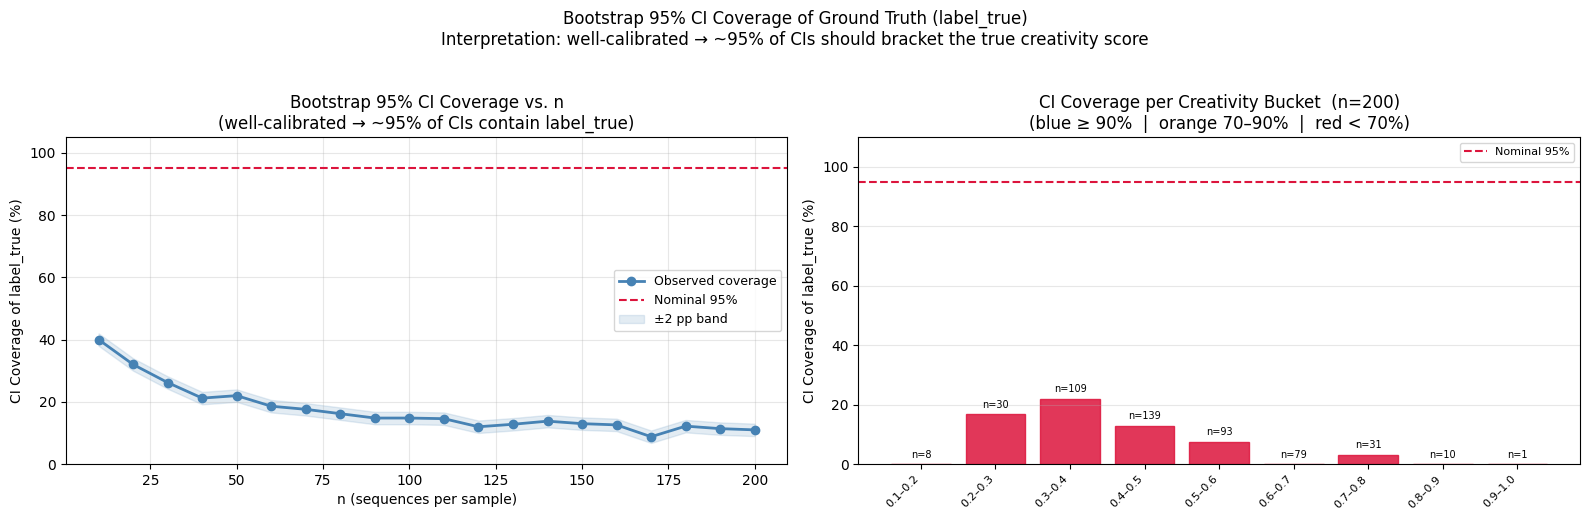

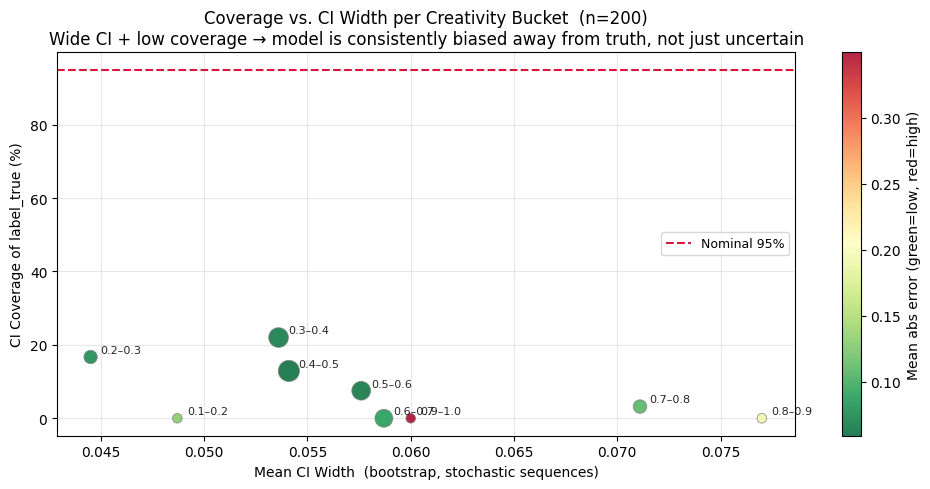

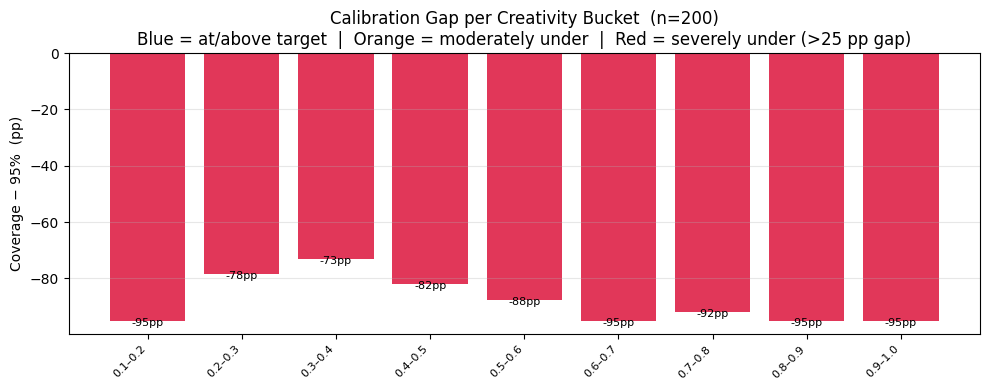


Calibration summary at n=200:
  Overall CI coverage:      11.0%  (target: 95%,  gap: -84.0 pp)
  Best-covered bucket:      0.3–0.4  (22.0%,  n=109)
  Worst-covered bucket:     0.1–0.2  (0.0%,  n=8)

  → SEVERE undercoverage: the model's stochastic CI is too narrow to bracket
    the true score — consistent directional bias dominates random variance.

  Buckets with severe undercoverage (<70%): 0.1–0.2, 0.2–0.3, 0.3–0.4, 0.4–0.5, 0.5–0.6, 0.6–0.7, 0.7–0.8, 0.8–0.9, 0.9–1.0
  → The model cannot estimate its own uncertainty in these creativity ranges.


In [9]:

# ============================================================
# CI COVERAGE OF label_true — Calibration Check
#   Does the 95% bootstrap CI actually contain the ground truth?
#   A well-calibrated model should hit ~95% coverage overall.
#   Low coverage in a bucket = the CI is too narrow / biased
#   in that creativity range → direct calibration failure.
# ============================================================

# ci_labeled has ci_bootstrap_width but not the bounds — join them from ci_all
ci_bounds = ci_all[['sample_key', 'n_target', 'ci_bootstrap_lower', 'ci_bootstrap_upper']]
ci_cov = ci_labeled.merge(ci_bounds, on=['sample_key', 'n_target'], how='inner')

# Binary: does the CI contain label_true?
ci_cov['ci_covers_true'] = (
    (ci_cov['label_true'] >= ci_cov['ci_bootstrap_lower']) &
    (ci_cov['label_true'] <= ci_cov['ci_bootstrap_upper'])
).astype(int)

print(f"Records with CI bounds: {len(ci_cov)}")
print(f"Null ci_bootstrap_lower:  {ci_cov['ci_bootstrap_lower'].isna().sum()}")
print(f"Null label_true:          {ci_cov['label_true'].isna().sum()}")

# ── 1. Overall coverage by n ────────────────────────────────
cov_by_n = (
    ci_cov
    .groupby('n_target')['ci_covers_true']
    .agg(coverage='mean', n_samples='count')
    .reset_index()
)
cov_by_n['coverage_pct'] = (cov_by_n['coverage'] * 100).round(1)

print("\nCI Coverage of label_true by n  (nominal target: 95%)")
print("─" * 45)
display(cov_by_n[['n_target', 'n_samples', 'coverage_pct']])

# ── 2. Per creativity-bucket coverage at best n ─────────────
best_n = int(ci_cov['n_target'].max())
df_cov_best = ci_cov[ci_cov['n_target'] == best_n].dropna(
    subset=['label_true', 'ci_bootstrap_lower', 'ci_bootstrap_upper', 'creativity_bucket']
).copy()

cov_bucket = (
    df_cov_best
    .groupby('creativity_bucket', observed=True)
    .agg(
        n_samples       =('ci_covers_true',       'count'),
        coverage_pct    =('ci_covers_true',        lambda x: round(x.mean() * 100, 1)),
        mean_ci_width   =('ci_bootstrap_width',    lambda x: round(x.mean(), 4)),
        mean_error      =('abs_prediction_error',  lambda x: round(x.mean(), 4)),
        mean_entropy    =('semantic_entropy',       lambda x: round(x.mean(), 4)),
    )
    .reset_index()
)

print(f"\nCI Coverage per Creativity Bucket at n={best_n}  (nominal: 95%)")
print("─" * 75)
print("  coverage_pct ≈ 95 → well-calibrated in that range")
print("  coverage_pct << 95 → CI is too narrow or systematically biased")
print("─" * 75)
display(cov_bucket)

# ── 3. Plot: coverage vs n + per-bucket bar chart ───────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: coverage vs n
ax = axes[0]
ax.plot(cov_by_n['n_target'], cov_by_n['coverage_pct'],
        marker='o', color='steelblue', linewidth=2, label='Observed coverage')
ax.axhline(95, color='crimson', linewidth=1.5, linestyle='--', label='Nominal 95%')
ax.fill_between(cov_by_n['n_target'],
                (cov_by_n['coverage_pct'] - 2).clip(0),
                (cov_by_n['coverage_pct'] + 2).clip(upper=105),
                alpha=0.15, color='steelblue', label='±2 pp band')
ax.set_xlabel('n (sequences per sample)')
ax.set_ylabel('CI Coverage of label_true (%)')
ax.set_title('Bootstrap 95% CI Coverage vs. n\n(well-calibrated → ~95% of CIs contain label_true)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Right: per-bucket bar chart, coloured by calibration quality
ax = axes[1]
x = np.arange(len(cov_bucket))
bars = ax.bar(x, cov_bucket['coverage_pct'], alpha=0.85)
for bar, val in zip(bars, cov_bucket['coverage_pct']):
    if val >= 90:
        bar.set_color('steelblue')
    elif val >= 70:
        bar.set_color('darkorange')
    else:
        bar.set_color('crimson')
ax.axhline(95, color='crimson', linewidth=1.5, linestyle='--', label='Nominal 95%')
ax.set_xticks(x)
ax.set_xticklabels(cov_bucket['creativity_bucket'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CI Coverage of label_true (%)')
ax.set_title(f'CI Coverage per Creativity Bucket  (n={best_n})\n(blue ≥ 90%  |  orange 70–90%  |  red < 70%)')
ax.set_ylim(0, 110)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, axis='y')
for bx, val, cnt in zip(x, cov_bucket['coverage_pct'], cov_bucket['n_samples']):
    ax.text(bx, val + 1.5, f'n={cnt}', ha='center', va='bottom', fontsize=7)

plt.suptitle(
    'Bootstrap 95% CI Coverage of Ground Truth (label_true)\n'
    'Interpretation: well-calibrated → ~95% of CIs should bracket the true creativity score',
    fontsize=12, y=1.03
)
plt.tight_layout()
plt.show()

# ── 4. Coverage vs CI Width scatter — sized by n, coloured by error ──
fig, ax = plt.subplots(figsize=(10, 5))
sc = ax.scatter(
    cov_bucket['mean_ci_width'], cov_bucket['coverage_pct'],
    c=cov_bucket['mean_error'], cmap='RdYlGn_r',
    s=(cov_bucket['n_samples'].clip(10, 1000) ** 0.6) * 12,
    alpha=0.85, edgecolors='grey', linewidths=0.6, zorder=3
)
plt.colorbar(sc, ax=ax, label='Mean abs error (green=low, red=high)')
ax.axhline(95, color='crimson', linewidth=1.5, linestyle='--', label='Nominal 95%')
for _, row_b in cov_bucket.iterrows():
    ax.annotate(
        str(row_b['creativity_bucket']),
        (row_b['mean_ci_width'], row_b['coverage_pct']),
        textcoords='offset points', xytext=(7, 3), fontsize=8, alpha=0.85
    )
ax.set_xlabel('Mean CI Width  (bootstrap, stochastic sequences)')
ax.set_ylabel('CI Coverage of label_true (%)')
ax.set_title(
    f'Coverage vs. CI Width per Creativity Bucket  (n={best_n})\n'
    'Wide CI + low coverage → model is consistently biased away from truth, not just uncertain'
)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── 5. Calibration gap: how far each bucket is from 95% ─────
cov_bucket['gap_from_95'] = (cov_bucket['coverage_pct'] - 95).round(1)

fig, ax = plt.subplots(figsize=(10, 4))
colors = ['steelblue' if g >= 0 else ('darkorange' if g >= -25 else 'crimson')
          for g in cov_bucket['gap_from_95']]
bars2 = ax.bar(np.arange(len(cov_bucket)), cov_bucket['gap_from_95'], color=colors, alpha=0.85)
ax.axhline(0, color='black', linewidth=1.2)
ax.set_xticks(np.arange(len(cov_bucket)))
ax.set_xticklabels(cov_bucket['creativity_bucket'].astype(str), rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Coverage − 95%  (pp)')
ax.set_title(
    f'Calibration Gap per Creativity Bucket  (n={best_n})\n'
    'Blue = at/above target  |  Orange = moderately under  |  Red = severely under (>25 pp gap)'
)
ax.grid(True, alpha=0.3, axis='y')
for bx, val in zip(np.arange(len(cov_bucket)), cov_bucket['gap_from_95']):
    ax.text(bx, val + (0.8 if val >= 0 else -1.8),
            f'{val:+.0f}pp', ha='center', fontsize=8)
plt.tight_layout()
plt.show()

# ── 6. Summary ───────────────────────────────────────────────
overall_cov = df_cov_best['ci_covers_true'].mean() * 100
worst_row   = cov_bucket.loc[cov_bucket['coverage_pct'].idxmin()]
best_row    = cov_bucket.loc[cov_bucket['coverage_pct'].idxmax()]
gap         = overall_cov - 95

print(f"\nCalibration summary at n={best_n}:")
print(f"  Overall CI coverage:      {overall_cov:.1f}%  (target: 95%,  gap: {gap:+.1f} pp)")
print(f"  Best-covered bucket:      {best_row['creativity_bucket']}  "
      f"({best_row['coverage_pct']:.1f}%,  n={int(best_row['n_samples'])})")
print(f"  Worst-covered bucket:     {worst_row['creativity_bucket']}  "
      f"({worst_row['coverage_pct']:.1f}%,  n={int(worst_row['n_samples'])})")
print()
if overall_cov < 80:
    print("  → SEVERE undercoverage: the model's stochastic CI is too narrow to bracket")
    print("    the true score — consistent directional bias dominates random variance.")
elif overall_cov < 90:
    print("  → MODERATE undercoverage: the CI brackets truth less than expected.")
    print("    The model has meaningful bias, especially in low-coverage buckets.")
elif overall_cov > 99:
    print("  → OVERCOVERAGE: CIs are wider than necessary — conservative, not harmful,")
    print("    but the model's stochastic spread is larger than its bias.")
else:
    print("  → Coverage near nominal: the stochastic CI is roughly well-calibrated overall.")
print()
severely_under = cov_bucket[cov_bucket['coverage_pct'] < 70]
if not severely_under.empty:
    buckets_str = ', '.join(severely_under['creativity_bucket'].astype(str))
    print(f"  Buckets with severe undercoverage (<70%): {buckets_str}")
    print(f"  → The model cannot estimate its own uncertainty in these creativity ranges.")
